<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/HeartCycle_full_code_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Algoritmo general

Mounted at /content/drive


Procesando 59146240: 100%|██████████| 74/74 [00:25<00:00,  2.93it/s]


 Segmentos guardados en CSV.

 Graficando 5 segmentos ICG aleatorios...


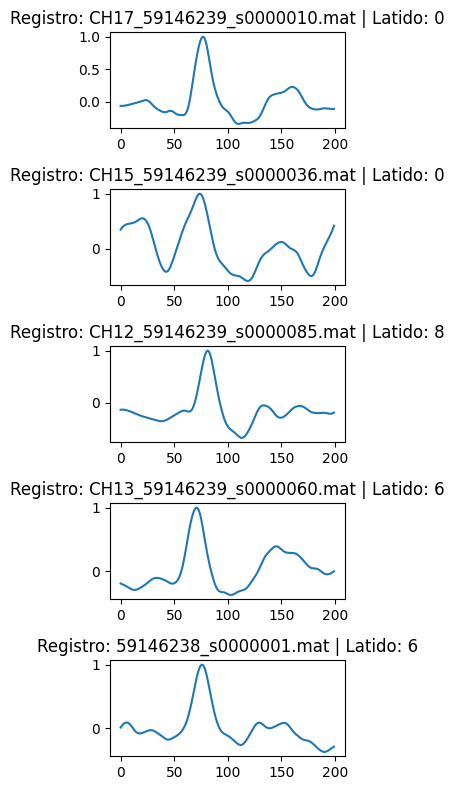

In [ ]:
# ============================
# --- FILTRADO DE SEÑALES ---
# ============================
from scipy.signal import butter, filtfilt, savgol_filter
import numpy as np
import h5py

FS = 198.46762  # Frecuencia de muestreo fija

def butter_bandpass_filter(data, lowcut=0.5, highcut=20, fs=FS, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, data)

def filtrar_icg(icg_raw, fs=FS):
    icg_bandpassed = butter_bandpass_filter(icg_raw, 0.5, 20, fs)
    icg_filtered = savgol_filter(icg_bandpassed, window_length=25, polyorder=3)
    return icg_filtered

# ============================
# --- PROCESAMIENTO DE DATOS ---
# ============================
import os
import pandas as pd
import scipy.io as sio
from tqdm import tqdm

def leer_measures(filepath):
    if filepath.endswith('.mat'):
        data = sio.loadmat(filepath)
        return data['measure']
    return None

def procesar_archivo(filepath):
    try:
        measures = leer_measures(filepath)
        if measures is None:
            return []

        ecg = measures[0, 1]['data'][0, 0].squeeze()
        r_peaks = (measures[2, 1]['data'][0, 0].flatten() * FS).astype(int)

        # Derivar la impedancia para obtener ICG
        impedance_data = measures[1, 1]['data'][0, 0]
        #obtenemos icg como derivada de la impedancia
        icg_raw = np.gradient(impedance_data.flatten())
        icg_filtrada = filtrar_icg(icg_raw)

        segmentos = []
        for i, r in enumerate(r_peaks):
            if r - 50 >= 0 and r + 150 < len(icg_filtrada):
                segmento = icg_filtrada[r - 50: r + 150]
                # Normalizar en amplitud (estandarizar)
                max_amplitude = np.max(np.abs(segmento))
                if max_amplitude == 0:
                    max_amplitude = 1
                segment_norm = segmento / max_amplitude

                segmentos.append({
                    'registro': os.path.basename(filepath),
                    'latido': i,
                    'icg_segment': segment_norm
                })
        return segmentos

    except Exception as e:
        print(f"Error en archivo {filepath}: {e}")
        return []

# ============================
# --- LOOP Y EXPORTACIÓN ---
# ============================
from google.colab import drive
drive.mount('/content/drive')

root_dir = '/content/drive/MyDrive/HeartCycle'
carpetas = ['59146237', '59146238', '59146239', '59146240']
resultados = []

for carpeta in carpetas:
    folder_path = os.path.join(root_dir, carpeta)
    for archivo in tqdm(os.listdir(folder_path), desc=f"Procesando {carpeta}"):
        if archivo.endswith('.mat'):
            full_path = os.path.join(folder_path, archivo)
            resultados.extend(procesar_archivo(full_path))

# Crear DataFrame y guardar
df_segments = pd.DataFrame(resultados)
df_segments.to_csv('/content/icg_segmentos_filtrados.csv', index=False)
print(" Segmentos guardados en CSV.")

# ============================
# --- VISUALIZACIÓN ---
# ============================
import matplotlib.pyplot as plt

# Visualiza 5 segmentos aleatorios
if not df_segments.empty:
    print("\n Graficando 5 segmentos ICG aleatorios...")
    muestras = df_segments.sample(n=5, random_state=42)

    plt.figure(figsize=(3, 8))
    for idx, row in enumerate(muestras.itertuples()):
        plt.subplot(5, 1, idx + 1)
        plt.plot(row.icg_segment)
        plt.title(f"Registro: {row.registro} | Latido: {row.latido}")
        plt.tight_layout()
    plt.show()


A continuación queremos crear un segundo dataset que a diferencia del anterior tendrá todos los subcomplejos a excepción del subcomplejo u. Esto se realiza para que posteriormente al realizar el clustering, aquellos subcomplejos u no introduzcan ruido ya que no proporcionan ninguna información útil sobre el icg.

Label(value='Introduce etiquetas para los segmentos mostrados:')

Text(value='', description='Etiquetas: ', placeholder='Escribe las etiquetas aquí')

Button(description='Enviar Etiquetas', style=ButtonStyle())

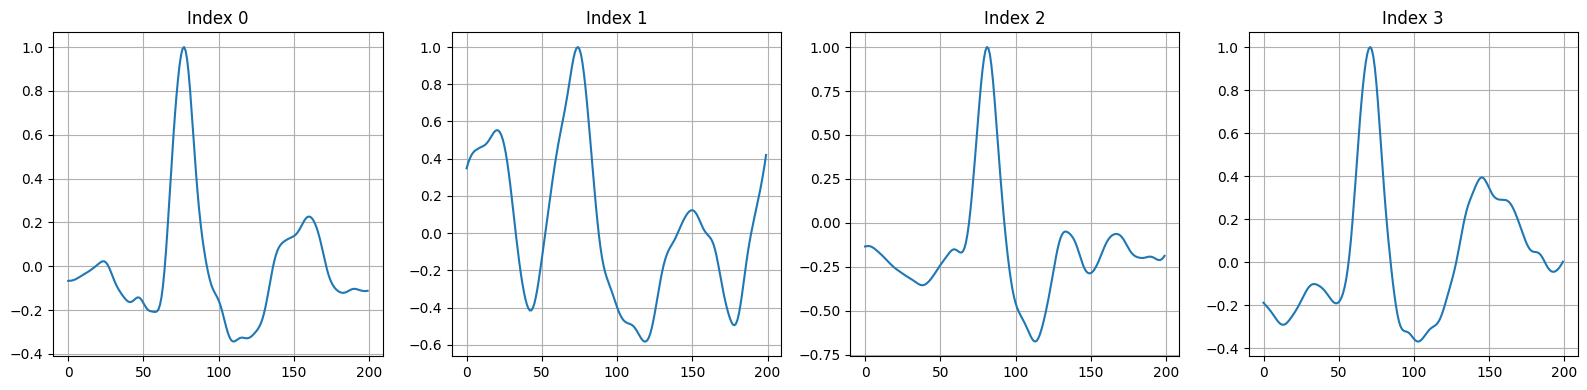

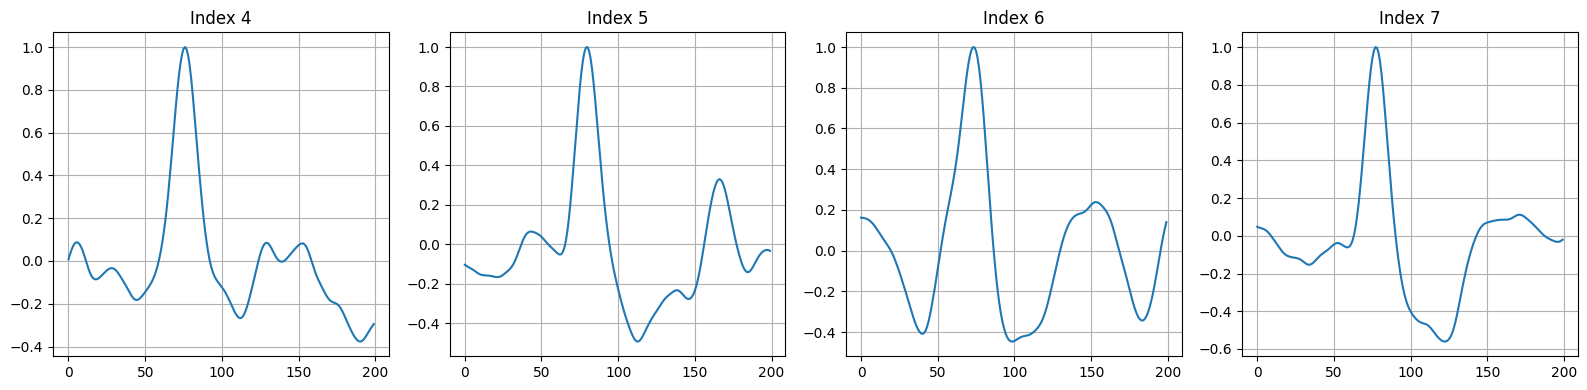

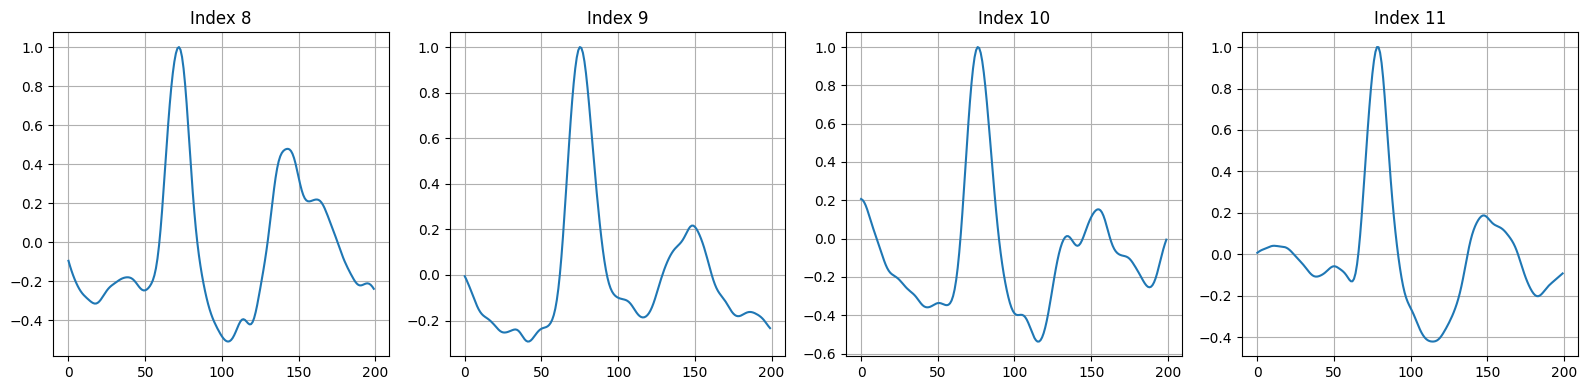

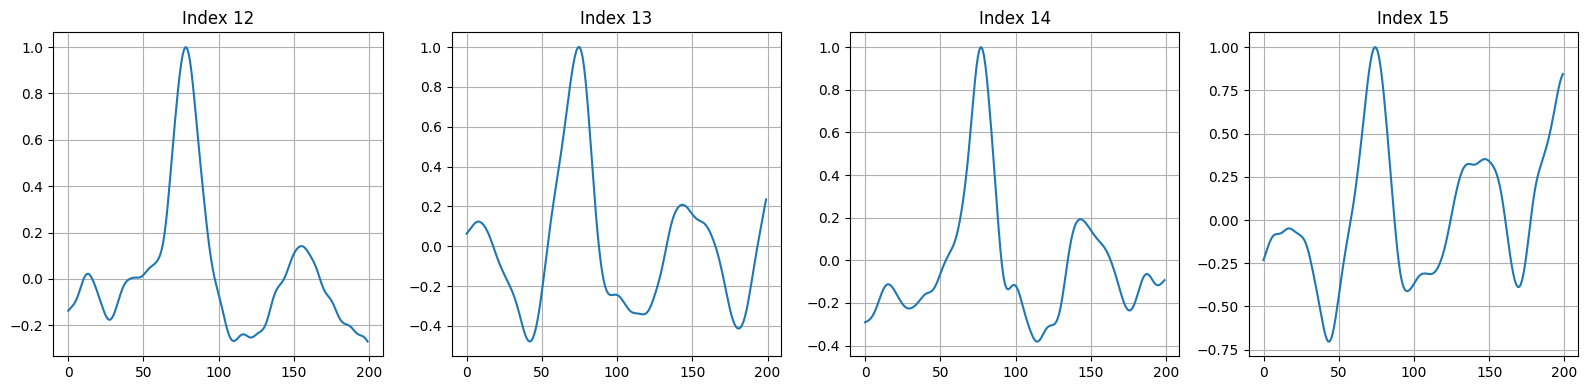

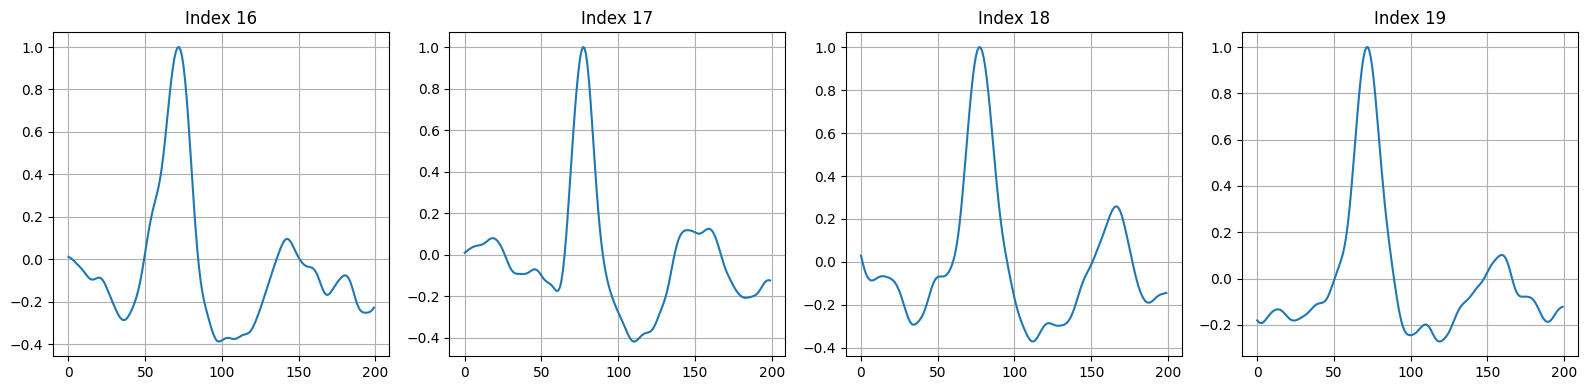

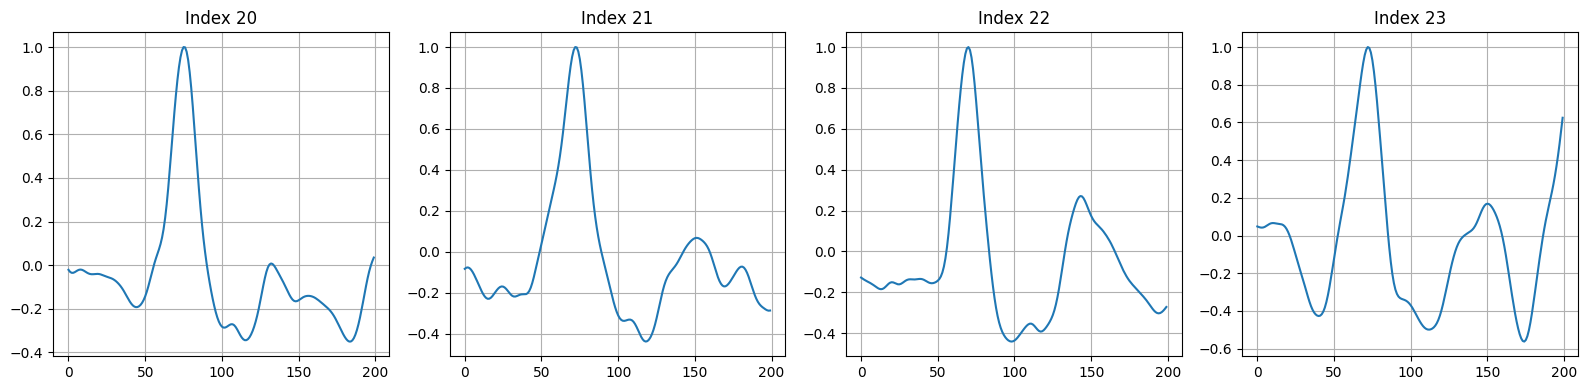

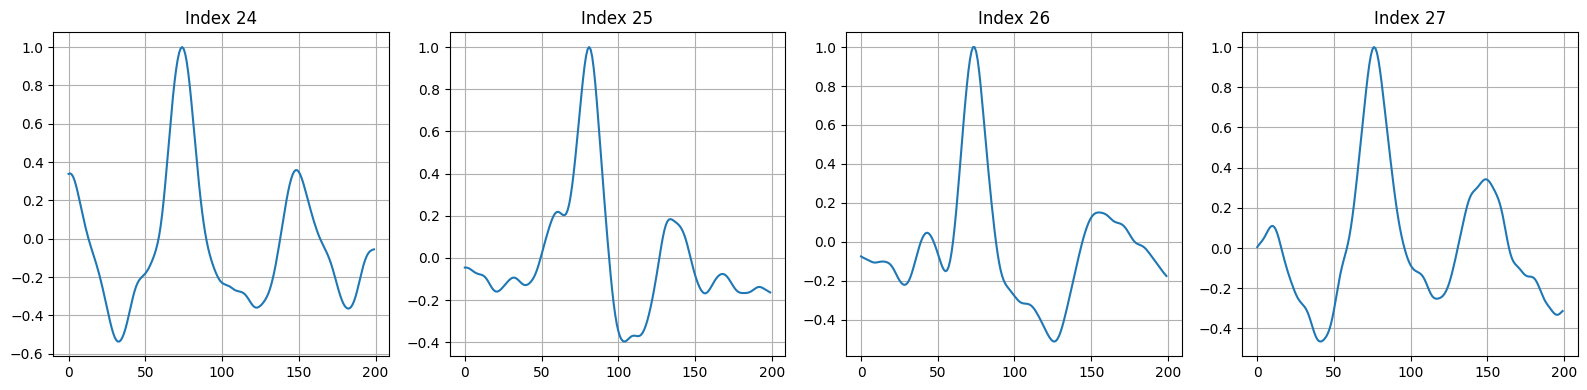

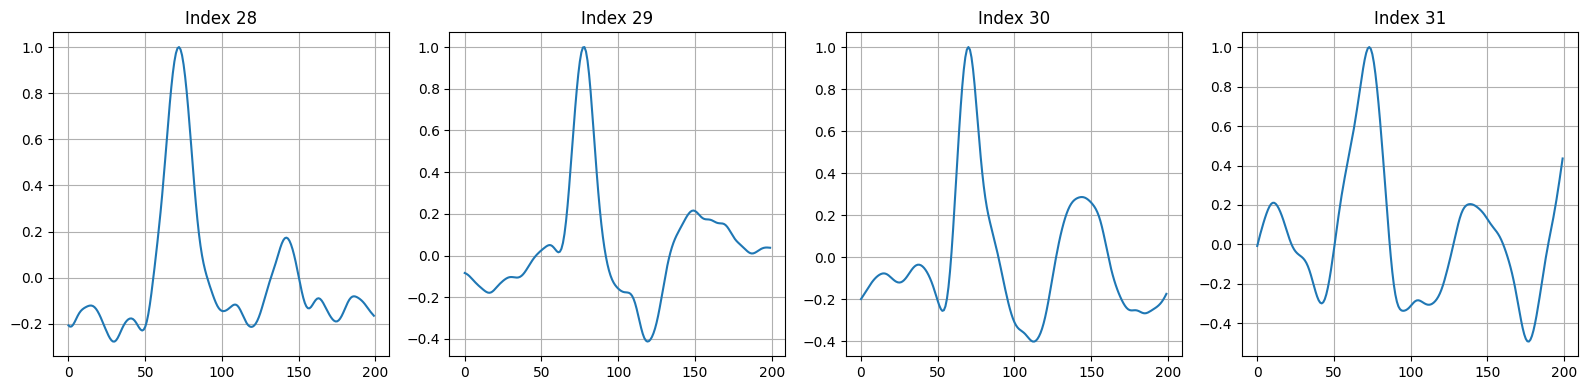

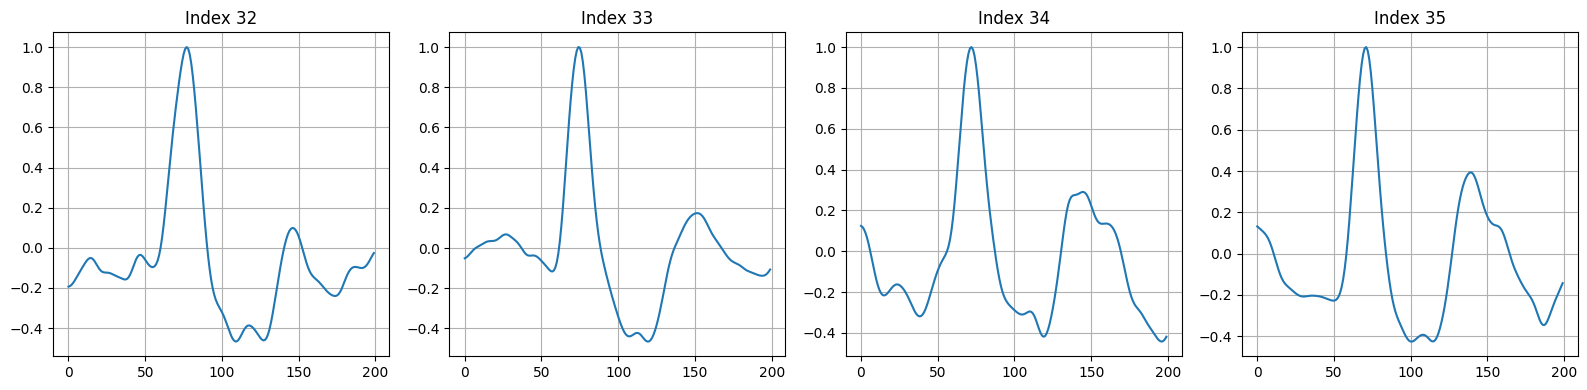

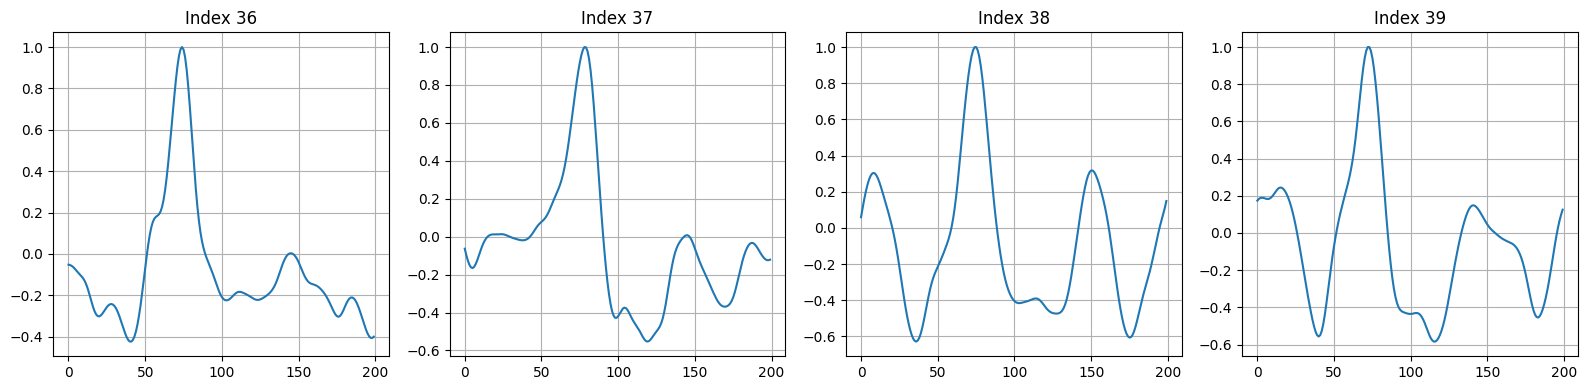

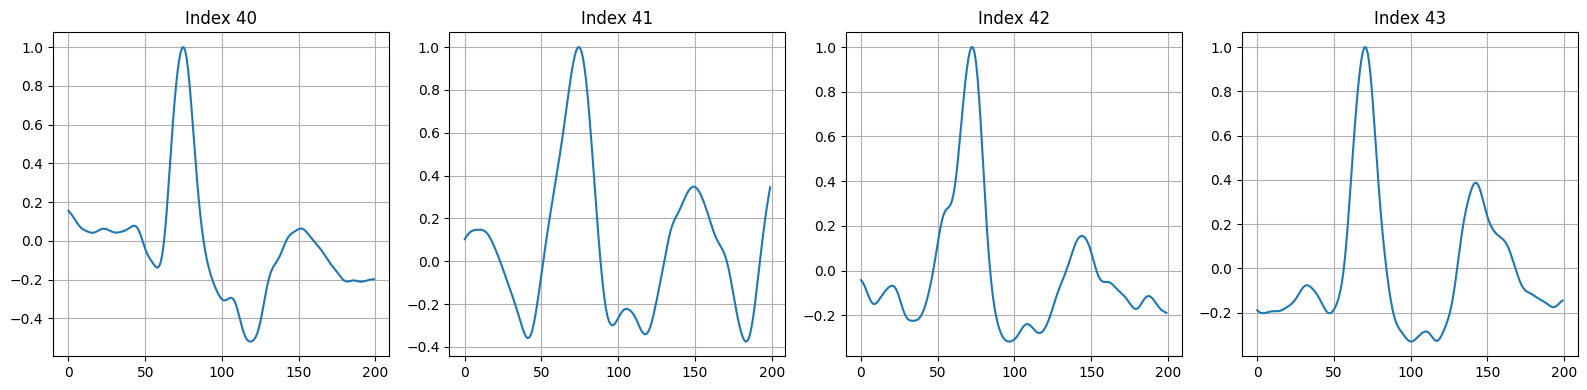

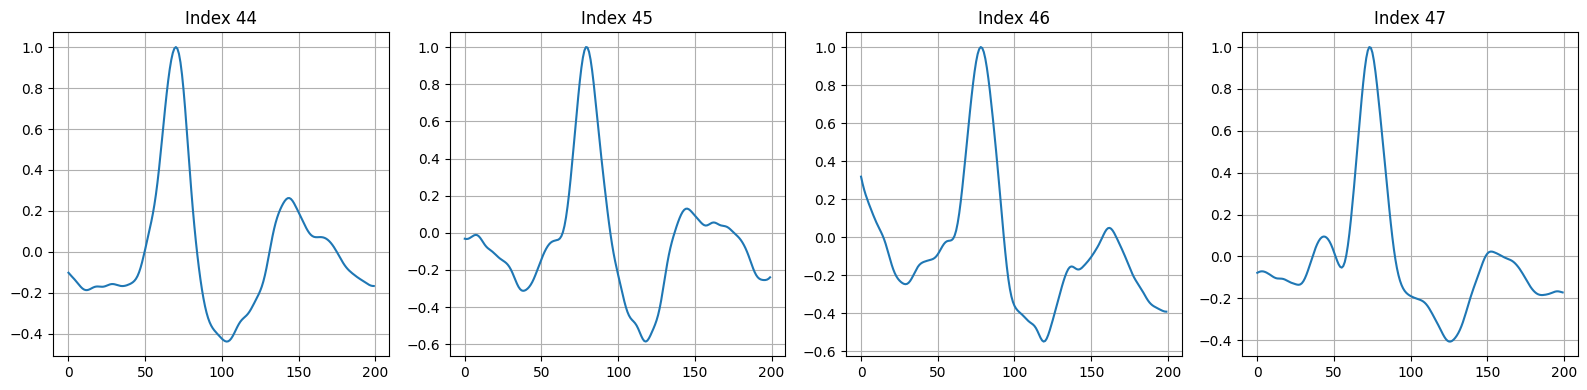

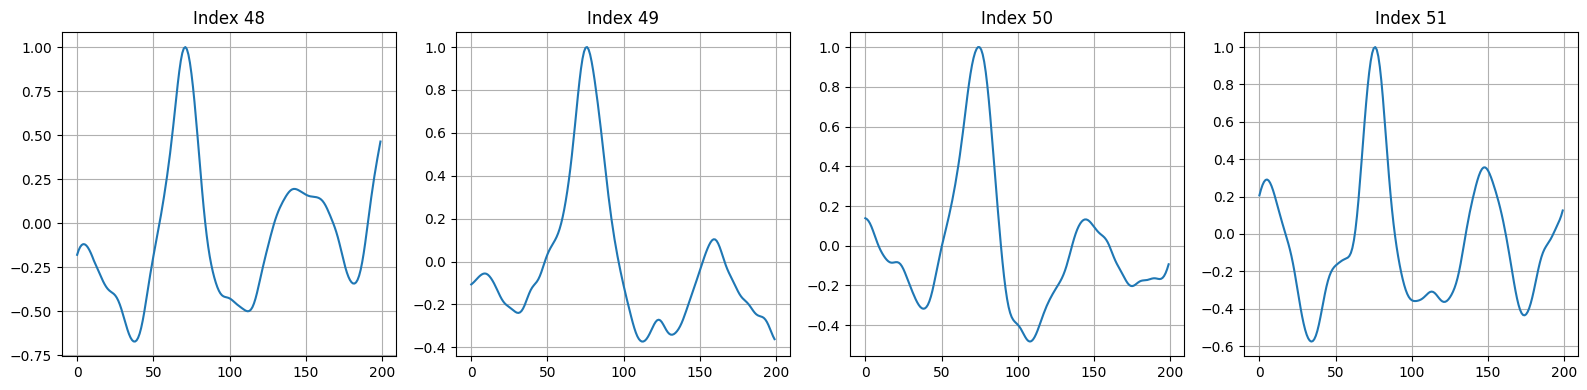

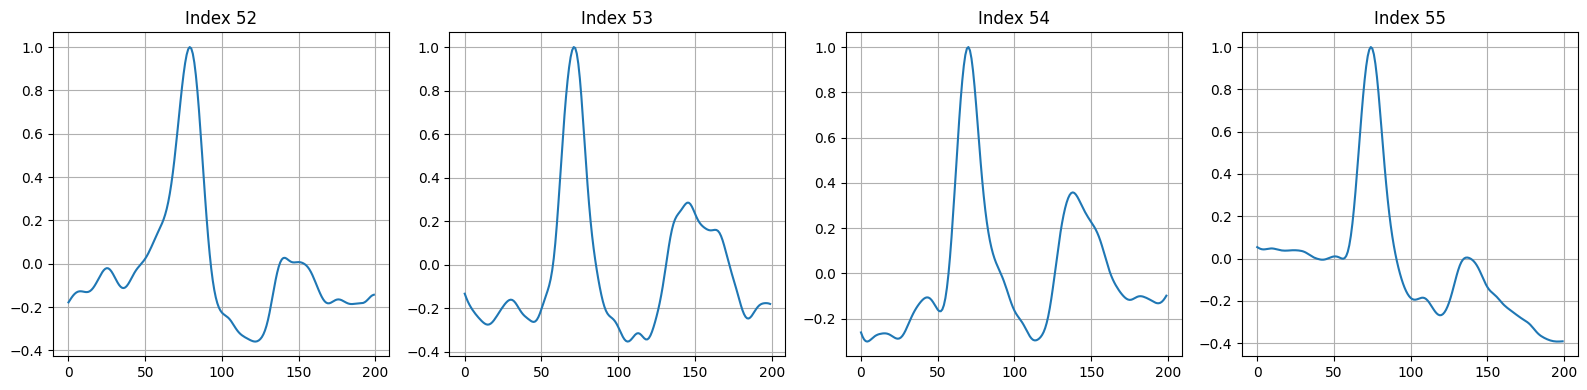

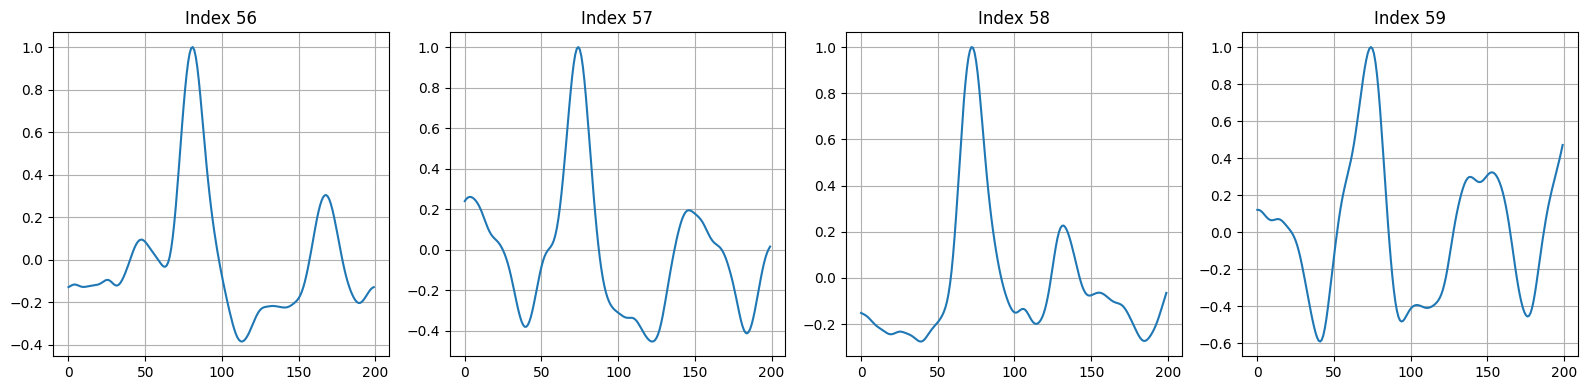

Etiquetado completado.
Segmentos guardados en CSV.


In [ ]:
import random
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Número de muestras para etiquetar manualmente
num_samples = 60
batch_size = 4    # Cuántos gráficos mostramos a la vez

# Seleccionar segmentos aleatorios
sampled_df = df_segments.sample(n=num_samples, random_state=42).reset_index(drop=True)

# Lista para almacenar las etiquetas
labels = []

# Función que se usará para actualizar las etiquetas
def on_button_click(b):
    global current_batch_index, labels, sampled_df, batch

    # Obtener las etiquetas del input y dividirlas
    batch_labels = text_input.value.upper().split()

    if len(batch_labels) == len(batch) and all(l in ['V', 'U'] for l in batch_labels):
        # Si las etiquetas son correctas, añadirlas al DataFrame
        labels.extend(batch_labels)
        current_batch_index += 1

        # Verificar si aún hay más lotes para etiquetar
        if current_batch_index < num_samples // batch_size:
            # Actualizar el gráfico y la solicitud de etiquetas
            update_batch()
        else:
            print("Etiquetado completado.")
            # Guardar el DataFrame con las etiquetas
            sampled_df['Label'] = labels
            sampled_df.to_csv("icg_labeled_V_U.csv", index=False)
            print("Segmentos guardados en CSV.")
            button.disabled = True
    else:
        print("Error: Debes introducir exactamente una etiqueta V o U por cada segmento mostrado.")

# Función para actualizar el gráfico y mostrar los nuevos segmentos a etiquetar
def update_batch():
    global batch, text_input, current_batch_index, label_request

    # Crear subgráficos para mostrar los segmentos
    batch_start = current_batch_index * batch_size
    batch_end = min(batch_start + batch_size, num_samples)
    batch = sampled_df.iloc[batch_start:batch_end]

    fig, axs = plt.subplots(1, len(batch), figsize=(16, 4))

    if len(batch) == 1:
        axs = [axs]  # Para que axs sea siempre iterable

    for ax, (_, row) in zip(axs, batch.iterrows()):
        segment = row['icg_segment']
        ax.plot(segment)
        ax.set_title(f"Index {row.name}")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

    # Actualizar el texto de la solicitud
    label_request.value = f"Introduce {len(batch)} etiquetas separadas por espacio (V para válido, U para inválido):"

# Inicializar el índice del lote actual
current_batch_index = 0

# Crear el cuadro de texto para introducir las etiquetas
text_input = widgets.Text(
    placeholder='Escribe las etiquetas aquí',
    description='Etiquetas: ',
    disabled=False
)

# Crear el botón para enviar las etiquetas
button = widgets.Button(description="Enviar Etiquetas")
button.on_click(on_button_click)

# Crear el texto de la solicitud
label_request = widgets.Label(value="Introduce etiquetas para los segmentos mostrados:")

# Mostrar la interfaz en Colab
display(label_request)
display(text_input)
display(button)

# Actualizar la visualización con los primeros segmentos
update_batch()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from scipy.stats import skew, kurtosis
import numpy as np

# Función para extraer características simples de cada segmento
def extract_features(segments):
    features = []
    for segment in segments:
        mean = np.mean(segment)
        std = np.std(segment)
        max_val = np.max(segment)
        min_val = np.min(segment)
        skewness = skew(segment)
        kurt = kurtosis(segment)
        features.append([mean, std, max_val, min_val, skewness, kurt])
    return np.array(features)

# Extraer características del df que yo he clasificado como U o V
X = extract_features(sampled_df['icg_segment'])
y = sampled_df['Label'].apply(lambda x: 1 if x == 'V' else 0)  # Convertir 'V' a 1 y 'U' a 0

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar el modelo Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Evaluar el modelo
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        18

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



In [ ]:
# Asumimos que df_segments contiene todos los segmentos restantes
#Extraemos características de todos los segmentos del df
X_all = extract_features(df_segments['icg_segment'])

# Predecir etiquetas para el resto de los segmentos
y_all_pred = rf.predict(X_all)

# Convertir las predicciones de 0 y 1 de nuevo a 'V' y 'U'
df_segments['Predicted_Label'] = ['V' if label == 1 else 'U' for label in y_all_pred]

# Guardar el DataFrame con las predicciones
df_segments.to_csv("icg_segments_with_predictions.csv", index=False)


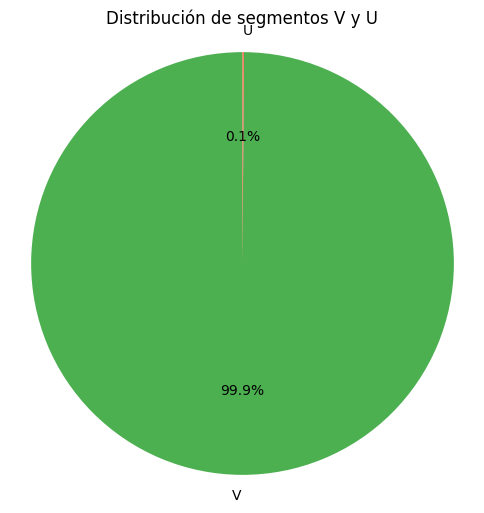

In [ ]:
# Contar la cantidad de segmentos de tipo V y U
label_counts = df_segments['Predicted_Label'].value_counts()

# Graficar distribución de segmentos V y U
plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#FF6347'])
plt.title("Distribución de segmentos V y U")
plt.axis('equal')  # Asegura que el gráfico sea un círculo
plt.show()


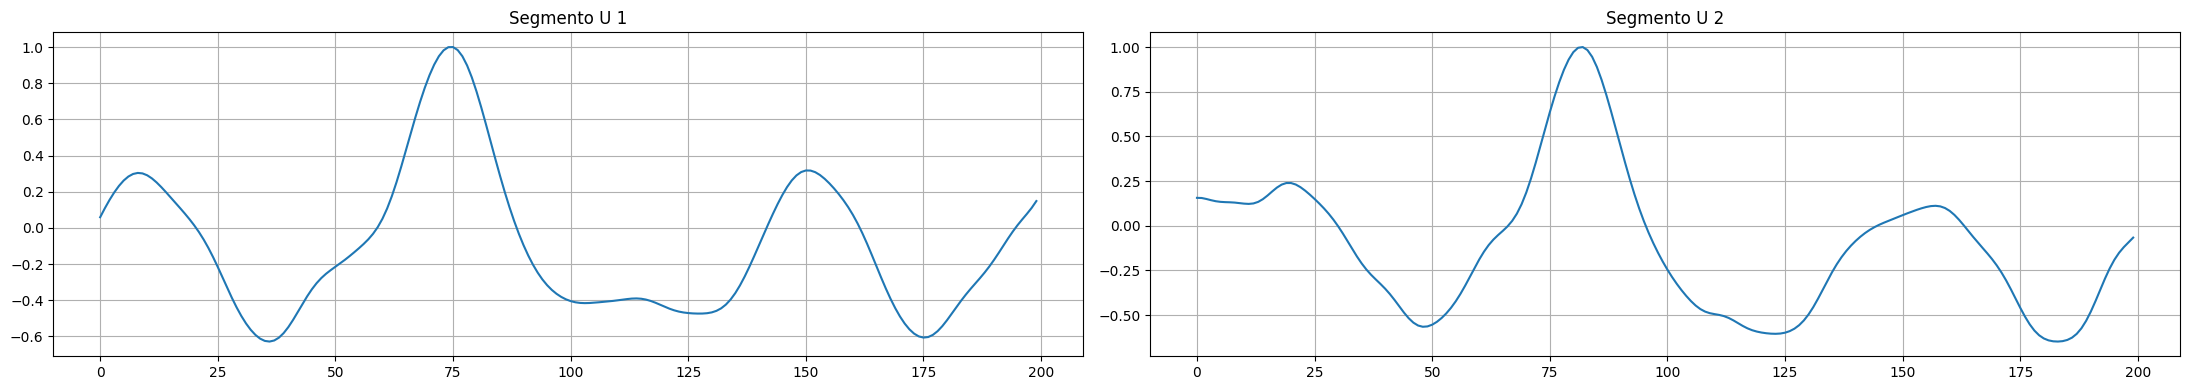

In [ ]:
# Filtrar los segmentos clasificados como 'U'
u_segments = df_segments[df_segments['Predicted_Label'] == 'U']

# Seleccionar un número aleatorio de segmentos 'U' para visualizar
num_segments_to_show = 2
random_u_segments = u_segments.sample(n=num_segments_to_show, random_state=42)

# Graficar los segmentos 'U' seleccionados
plt.figure(figsize=(22, 4))

for i, (_, row) in enumerate(random_u_segments.iterrows()):
    plt.subplot(1, num_segments_to_show, i + 1)
    plt.plot(row['icg_segment'])
    plt.title(f"Segmento U {i+1}")
    plt.grid(True)

plt.tight_layout()
plt.show()


###Algoritmo de delineación de puntos característicos:

*Para comprobar que el algoritmo está ubicando el punto en el lugar óptimo he implementado un plot de un segmento random.

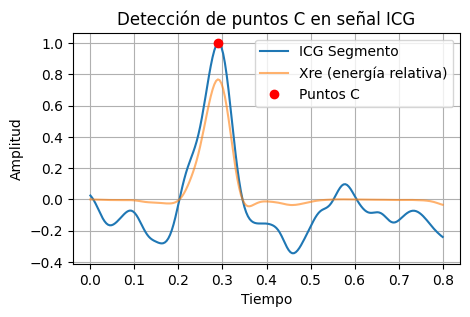

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

#C-POINT DETECTION

def relative_energy(signal, fs, long_win=0.95, short_win=0.14):
    long_len = int(long_win * fs)
    short_len = int(short_win * fs)
    Xre = np.zeros_like(signal)

    for n in range(len(signal)):
        i1 = max(0, n - long_len // 2)
        i2 = min(len(signal), n + long_len // 2)
        long_energy = np.sum(signal[i1:i2] ** 2)

        j1 = max(0, n - short_len // 2)
        j2 = min(len(signal), n + short_len // 2)
        short_energy = np.sum(signal[j1:j2] ** 2)

        if long_energy != 0:
            c = short_energy / long_energy
            Xre[n] = signal[n] * c
    return Xre

def detect_C_peaks(icg_filtered, fs):
    Xre = relative_energy(icg_filtered, fs)

    # Thresholds
    sorted_peaks = np.sort(Xre[Xre > np.mean(Xre)])
    maxval = sorted_peaks[-2] if len(sorted_peaks) > 1 and sorted_peaks[-2] > np.mean(Xre) else sorted_peaks[-1]

    Thr_max = 0.2 * maxval
    Thr_min = 0.02 * maxval

    C_peaks = []
    active = False
    start_idx = 0

    for i in range(1, len(Xre)):
        if not active and Xre[i] > Thr_max:
            active = True
            start_idx = i
        elif active and Xre[i] < Thr_min:
            end_idx = i
            peak_idx = start_idx + np.argmax(Xre[start_idx:end_idx])
            if len(C_peaks) == 0 or (peak_idx - C_peaks[-1]) > int(0.25 * fs):
                C_peaks.append(peak_idx)
            active = False

    # Filtrar según intervalos C-C
    final_C_peaks = []
    for i, p in enumerate(C_peaks):
        if i < 5:
            final_C_peaks.append(p)
        else:
            prev_cc = np.diff(final_C_peaks[-5:])
            if len(prev_cc) == 5:
                avg_cc = np.mean(prev_cc)
                if (p - final_C_peaks[-1]) > 1.7 * avg_cc:
                    final_C_peaks.append(p)
            else:
                final_C_peaks.append(p)

    return np.array(final_C_peaks), Xre

#Cogemos un segmento de icg cuya etiqueta sea V
icg_segment = v_segments['icg_segment'].iloc[100]
fs=250
C_peaks, Xre = detect_C_peaks(icg_segment, fs)

#Definimos el tiempo para representar en función del tiempo en lugar de muestras
tiempo = np.linspace(0, len(icg_segment)/fs, len(icg_segment))

# Representación
plt.figure(figsize=(5, 3))
plt.plot(tiempo, icg_segment, label="ICG Segmento")
plt.plot(tiempo, Xre, label="Xre (energía relativa)", alpha=0.6)
plt.plot(tiempo[C_peaks], icg_segment[C_peaks], 'ro', label="Puntos C")
plt.legend()
plt.title("Detección de puntos C en señal ICG")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


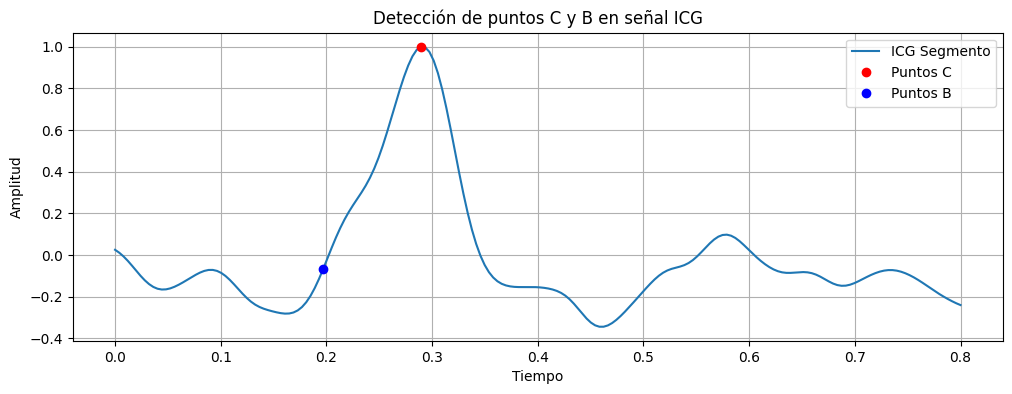

In [ ]:
#B-POINT DETECTION
def find_B_point(icg_segment, Cpos, fs, Afrac=0.2, Bslope1=0.11, Bslope2=0.08):
    # Paso 1: calcular límites de la ventana de búsqueda
    BlimL = max(0, int(Cpos - 0.09 * fs))  # 80 ms antes del C
    C_amp = icg_segment[Cpos]

    # Buscar BlimR: el índice más cercano a la izquierda donde la señal < Afrac * C_amp
    for i in range(Cpos - 1, BlimL, -1):
        if icg_segment[i] <= Afrac * C_amp:
            BlimR = i
            break
    else:
        BlimR = BlimL  # Si no se encuentra, que sea igual al límite inferior

    # Derivada primera (pendiente) de la señal
    slope = np.gradient(icg_segment)

    # Paso 2: búsqueda con Bslope1
    for i in range(BlimR, BlimL, -1):
        if (i > 0 and (icg_segment[i] < icg_segment[i-1])) or abs(slope[i]) > Bslope1:
            return i

    # Paso 3: búsqueda con Bslope2
    for i in range(BlimR, BlimL, -1):
        if abs(slope[i]) > Bslope2:
            return i

    # Paso 4: si no se encuentra, retornar el mínimo de la ventana
    search_region = icg_segment[BlimL:BlimR+1]
    return BlimL + np.argmin(search_region)

B_points = []
for Cpos in C_peaks:
    B_idx = find_B_point(icg_segment, Cpos, fs)
    B_points.append(B_idx)

# Visualización
plt.figure(figsize=(12, 4))
plt.plot(tiempo, icg_segment, label="ICG Segmento")
plt.plot(tiempo[C_peaks], icg_segment[C_peaks], 'ro', label="Puntos C")
plt.plot(tiempo[B_points], icg_segment[B_points], 'bo', label="Puntos B")
plt.legend()
plt.title("Detección de puntos C y B en señal ICG")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


Aquí estoy teniendo un inconveniente y es que al la señal aún ser un poco ruidosa, detecta muvhos mínimos locales que realmente no son puntos X sino que son ruido. Es por ello que a continuación aplicaremos un filtro de suavizado de la señal. Además, también se han añadido otras restricciones entre X1 y X2.

<ipython-input-61-72a602da62bb>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  start = max(int(C_index + CXmin_samp), 0)
<ipython-input-61-72a602da62bb>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)


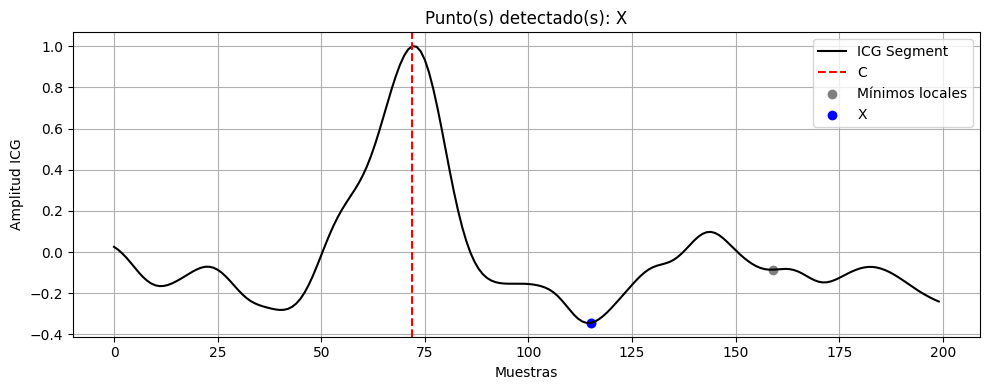

{'caso': 'X', 'X': np.int64(115)}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema
from scipy.ndimage import gaussian_filter1d

def detectar_punto_X(icg_segment, C_index, fs, plot=False, suavizar=True):

    # 1. Definir ventana temporal (0.1s a 0.4s después de C)
    CXmin_s, CXmax_s = 0.05, 0.4
    CXmin_samp, CXmax_samp = int(fs * CXmin_s), int(fs * CXmax_s)
    start = max(int(C_index + CXmin_samp), 0)
    end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)
    ventana = icg_segment[start:end]

    if len(ventana) < 3:
        return {"caso": "ninguno", "mensaje": "Ventana demasiado corta"}

    # 2. Suavizar señal si está activado
    if suavizar:
        ventana = gaussian_filter1d(ventana, sigma=1)

    # 3. Detectar mínimos locales
    min_indices = argrelextrema(ventana, np.less)[0]
    if len(min_indices) == 0:
        return {"caso": "ninguno", "mensaje": "No se detectaron mínimos locales"}

    # 4. Detectar mínimo global
    abs_min_idx = np.argmin(ventana)

    # 5. Clasificación según mínimos detectados
    if len(min_indices) == 1:
        idx = min_indices[0]
        if idx == abs_min_idx and (C_index + 0.07 <= idx <= C_index + 0.22):
            resultado = {"caso": "X1", "X1": idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) == 2:
        # Tomar los dos primeros mínimos locales
        X1_idx = min_indices[0]
        X2_idx = min_indices[1]

        # Comparar amplitudes
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        amplitud_umbral = 0.05  # Puedes ajustar este valor según tu dataset
        idx = min_indices[0]

        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif idx == abs_min_idx and (C_index + 0.07 <= idx <= C_index + 0.22):
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X1_idx] > ventana[X2_idx]:
            resultado = {"caso": "X", "X": X2_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) >= 3:
        # Tomar los tres primeros mínimos locales
        X1_idx = min_indices[0]
        X2_idx = min_indices[1]
        X3_idx = min_indices[2]

        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        amplitud_umbral = 0.05  # Puedes ajustar este valor según tu dataset
        idx = min_indices[0]

        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}

        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}

        elif idx == abs_min_idx and (C_index + 0.07 <= idx <= C_index + 0.22):
            resultado = {"caso": "X1", "X1": idx}

        elif ventana[X3_idx] < ventana[X2_idx]:
            resultado = {"caso": "X", "X": X3_idx}

        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    # 6. Graficar resultados
    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(icg_segment, label='ICG Segment', color='black')
        plt.axvline(x=C_index, color='red', linestyle='--', label='C')

        # Ajustar índices locales a posición original
        min_plot_idx = min_indices + start
        plt.scatter(min_plot_idx, icg_segment[min_plot_idx], color='gray', label='Mínimos locales')

        if resultado["caso"] == "X":
            plt.scatter(resultado["X"] + start, icg_segment[resultado["X"] + start], color='blue', label='X')
        elif resultado["caso"] == "X1":
            plt.scatter(resultado["X1"] + start, icg_segment[resultado["X1"] + start], color='orange', label='X1')
        elif resultado["caso"] == "X1_X2":
                plt.scatter(resultado["X1"] + start, icg_segment[resultado["X1"] + start],
                color='orange', label='X1')
                plt.scatter(resultado["X2"] + start, icg_segment[resultado["X2"] + start],
                color='blue', label='X2')
        plt.title(f"Punto(s) detectado(s): {resultado['caso']}")
        plt.xlabel("Muestras")
        plt.ylabel("Amplitud ICG")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


    # Ajustar índices al segmento original
    if resultado["caso"] == "X":
        resultado["X"] = resultado["X"] + start
    elif resultado["caso"] == "X1":
        resultado["X1"] = resultado["X1"] + start
    elif resultado["caso"] == "X1_X2":
        resultado["X1"] = resultado["X1"] + start
        resultado["X2"] = resultado["X2"] + start

    return resultado

segmento = v_segments['icg_segment'].iloc[100]
fs = 250
C_index, _ = detect_C_peaks(segmento, fs)

resultado = detectar_punto_X(segmento, C_index, fs, plot=True)
print(resultado)

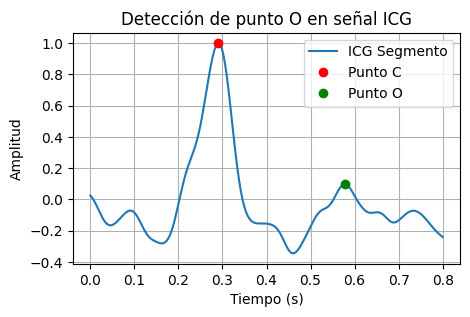

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

def detect_O_point(segment, C_index, fs):

    # Zona de búsqueda: 0.1s a 0.5s después del punto C
    start_search = C_index + int(0.2 * fs)  # 0.2 segundos después de C
    end_search = C_index + int(0.5 * fs)    # 0.5 segundos después de C

    # Asegurar que los índices no se salgan del rango
    end_search = min(end_search, len(segment))

    # Extraer la región de búsqueda
    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None  # No hay espacio para buscar

    # Buscar máximos locales
    peaks, _ = signal.find_peaks(search_region)

    if len(peaks) == 0:
        return None  # No se encontró ningún máximo local

    # Elegir el pico de mayor amplitud (el más alto)
    peak_amplitudes = search_region[peaks]
    max_peak_idx = peaks[np.argmax(peak_amplitudes)]

    # Convertir índice relativo a índice absoluto en el segmento
    O_index = start_search + max_peak_idx
    return O_index

# Suponiendo que ya tienes detectados los puntos C en los segmentos
# Si se ha detectado al menos un punto C
if len(C_peaks) > 0:
    C_idx = C_peaks[0]  # Suponiendo un solo punto C por segmento
    O_idx = detect_O_point(icg_segment, C_idx, fs)

    # Representación
    tiempo = np.linspace(0, len(icg_segment)/fs, len(icg_segment))
    plt.figure(figsize=(5, 3))
    plt.plot(tiempo, icg_segment, label="ICG Segmento")
    plt.plot(tiempo[C_idx], icg_segment[C_idx], 'ro', label="Punto C")
    if O_idx is not None:
        plt.plot(tiempo[O_idx], icg_segment[O_idx], 'go', label="Punto O")
    plt.legend()
    plt.title("Detección de punto O en señal ICG")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.show()


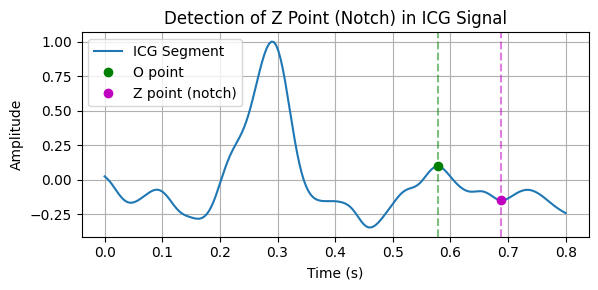

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

def detect_Z_point(segment, O_index, fs):
    # Define search window (start just after O, up to 0.1s after)
    start_search = O_index + int(0.005 * fs)
    end_search = O_index + int(0.15 * fs)
    end_search = min(end_search, len(segment))

    # Extract search region
    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None

    # Invert the signal to find local minima as peaks
    inverted_region = -search_region
    peaks, _ = signal.find_peaks(inverted_region)

    if len(peaks) == 0:
        return None  # No local minima found

    # Choose the deepest local minimum (notch)
    valley_amplitudes = search_region[peaks]
    min_peak_idx = peaks[np.argmin(valley_amplitudes)]

    # Convert to absolute index
    Z_index = start_search + min_peak_idx
    return Z_index

# Example of usage (assuming icg_segment, fs, and O_idx are defined)
Z_idx = detect_Z_point(icg_segment, O_idx, fs)

# Time vector for plotting
tiempo = np.linspace(0, len(icg_segment)/fs, len(icg_segment))

# Plotting the ICG signal with O and Z points
plt.figure(figsize=(6, 3))
plt.plot(tiempo, icg_segment, label="ICG Segment")
plt.plot(tiempo[O_idx], icg_segment[O_idx], 'go', label="O point")
if Z_idx is not None:
    plt.plot(tiempo[Z_idx], icg_segment[Z_idx], 'mo', label="Z point (notch)")
    plt.axvline(tiempo[Z_idx], color='m', linestyle='--', alpha=0.5)
plt.axvline(tiempo[O_idx], color='g', linestyle='--', alpha=0.5)
plt.title("Detection of Z Point (Notch) in ICG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


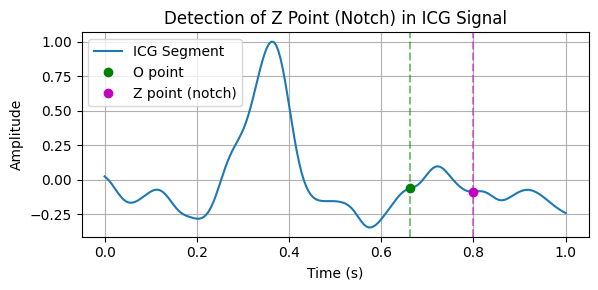

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

def detect_Z_point(segment, O_index, fs):
    # Define search window (start just after O, up to 0.1s after)
    start_search = O_index + int(0.005 * fs)
    end_search = O_index + int(0.15 * fs)
    end_search = min(end_search, len(segment))

    # Extract search region
    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None

    # Invert the signal to find local minima as peaks
    inverted_region = -search_region
    peaks, _ = signal.find_peaks(inverted_region)

    if len(peaks) == 0:
        return None  # No local minima found

    # Choose the first local minimum
    Z_index = start_search + peaks[0]
    return Z_index

# Example of usage (assuming icg_segment, fs, and O_idx are defined)
Z_idx = detect_Z_point(icg_segment, O_idx, fs)

# Time vector for plotting
tiempo = np.linspace(0, len(icg_segment)/fs, len(icg_segment))

# Plotting the ICG signal with O and Z points
plt.figure(figsize=(6, 3))
plt.plot(tiempo, icg_segment, label="ICG Segment")
plt.plot(tiempo[O_idx], icg_segment[O_idx], 'go', label="O point")
if Z_idx is not None:
    plt.plot(tiempo[Z_idx], icg_segment[Z_idx], 'mo', label="Z point (notch)")
    plt.axvline(tiempo[Z_idx], color='m', linestyle='--', alpha=0.5)
plt.axvline(tiempo[O_idx], color='g', linestyle='--', alpha=0.5)
plt.title("Detection of Z Point (Notch) in ICG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-24-e095963c8b84>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  start = max(int(C_index + CXmin_samp), 0)
<ipython-input-24-e095963c8b84>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)


Usando X_idx en detectar_punto_Y: 111
No se detectaron mínimos locales entre X y O.


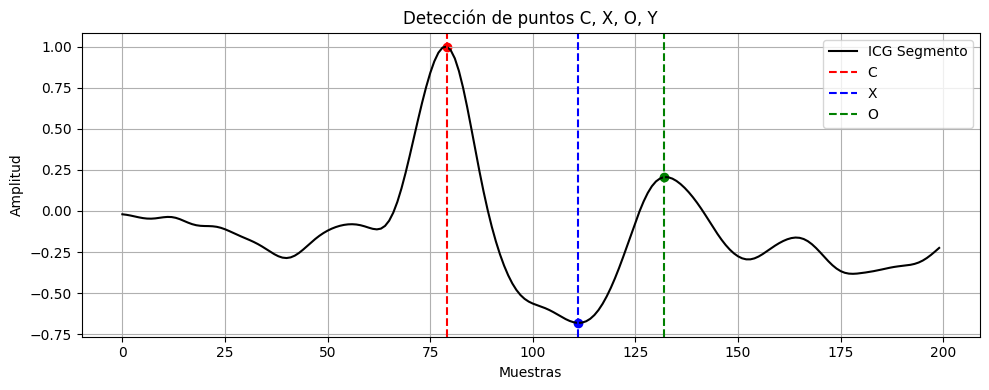

In [ ]:
from scipy.signal import argrelextrema
import matplotlib.pyplot as plt
import numpy as np

def detectar_punto_Y(icg_segment, resultado_X, O_index):
    # Determinar índice de inicio según el caso X
    if resultado_X["caso"] == "X":
        X_idx = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        X_idx = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        X_idx = resultado_X["X2"]  # usar X2 en este caso
    else:
        print("No se puede detectar Y: caso X no válido.")
        return None

    print("Usando X_idx en detectar_punto_Y:", X_idx)

    # Validar que X esté antes que O
    if X_idx >= O_index:
        print("No se puede detectar Y: X ocurre después de O.")
        return None

    # Extraer segmento entre X y O
    ventana_Y = icg_segment[X_idx:O_index + 1]

    # Buscar mínimos locales en esta ventana
    min_indices = argrelextrema(ventana_Y, np.less)[0]

    if len(min_indices) == 0:
        print("No se detectaron mínimos locales entre X y O.")
        return None

    # Tomar el mínimo local de menor amplitud
    Y_rel_idx = min_indices[np.argmin(ventana_Y[min_indices])]
    Y_abs_idx = X_idx + Y_rel_idx

    return Y_abs_idx


def plot_segmento_con_puntos(segmento, C_idx=None, X_idx=None, O_idx=None, Y_idx=None):
    plt.figure(figsize=(10, 4))
    plt.plot(segmento, label="ICG Segmento", color='black')

    if C_idx is not None:
        plt.axvline(x=C_idx, color='red', linestyle='--', label="C")
        plt.scatter([C_idx], [segmento[C_idx]], color='red')

    if X_idx is not None:
        plt.axvline(x=X_idx, color='blue', linestyle='--', label="X")
        plt.scatter([X_idx], [segmento[X_idx]], color='blue')

    if O_idx is not None:
        plt.axvline(x=O_idx, color='green', linestyle='--', label="O")
        plt.scatter([O_idx], [segmento[O_idx]], color='green')

    if Y_idx is not None:
        plt.axvline(x=Y_idx, color='magenta', linestyle='--', label="Y")
        plt.scatter([Y_idx], [segmento[Y_idx]], color='magenta')

    plt.legend()
    plt.title("Detección de puntos C, X, O, Y")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


segmento = v_segments['icg_segment'].iloc[1000]
fs = 250
C_index, _ = detect_C_peaks(segmento, fs)
resultado = detectar_punto_X(segmento, C_index, fs, plot=False)
C_idx = C_index[0]
O_idx = detect_O_point(segmento, C_idx, fs)
Y_idx = detectar_punto_Y(segmento, resultado, O_idx)

# Aquí usas la función externa para plotear todos los puntos
if resultado["caso"] == "X":
    X_idx = resultado["X"]
elif resultado["caso"] == "X1":
    X_idx = resultado["X1"]
elif resultado["caso"] == "X1_X2":
    X_idx = resultado["X2"]
else:
    X_idx = None

plot_segmento_con_puntos(segmento, C_idx=C_index[0], X_idx=X_idx, O_idx=O_idx, Y_idx=Y_idx)

[200]


<ipython-input-10-d9768d59de0d>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v_segments['Segment_partial'] = v_segments['icg_segment'].apply(lambda x: x[int(0.42*len(x)):])


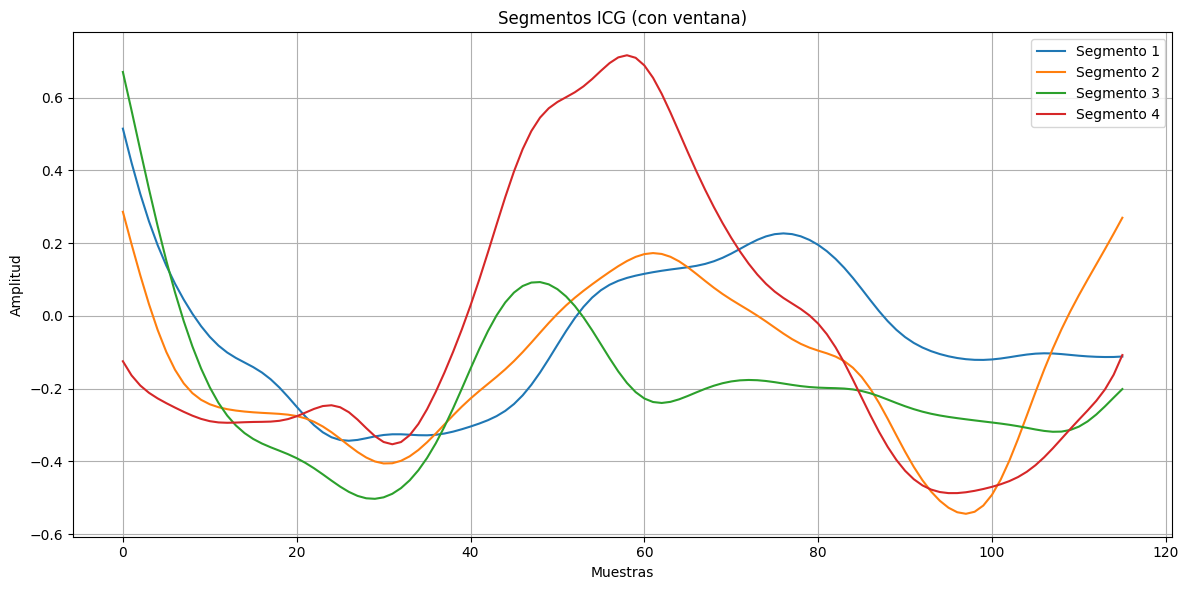

(1946, 116)


In [ ]:
import numpy as np

#Todos los segmentos V deben tener la misma longitud
segment_lengths = v_segments['icg_segment'].apply(len)
print(segment_lengths.unique())

#Para aplicar técnicas de clustering no nos quedamos con todo el segmento sino con la parte XYOZ que es la que realmente presenta variabilidad de
#unos subcomplejos a otros.
v_segments['Segment_partial'] = v_segments['icg_segment'].apply(lambda x: x[int(0.42*len(x)):])

# Seleccionar 4 segmentos aleatorios de la columna 'Segment_partial'
sampled_segments = v_segments['Segment_partial'].sample(4, random_state=42).reset_index(drop=True)

# Crear la figura para ver la ventana temporal que estamos cogiendo
plt.figure(figsize=(12, 6))
for i, segment in enumerate(sampled_segments):
    plt.plot(segment, label=f'Segmento {i+1}')

plt.title('Segmentos ICG (con ventana)')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


X = np.stack(v_segments['Segment_partial'].values)
print(X.shape)  # Debe ser (n_segmentos, longitud_segmento)
#Puedes observar que el número de segmentos cambia según se consideren los totales: df_segments['Segment'] o únicamente los subcomplejos V:
#v_segments['Segment']


In [ ]:
# Filtrar los segmentos clasificados como 'V' (válidos)
v_segments = df_segments[df_segments['Predicted_Label'] == 'V']
#A partir de ahora he de emplear esto apra referirme a los segmentos de icg filtrados (sin los subcomplejos u)

# Guardar los segmentos V en un nuevo archivo CSV
v_segments.to_csv("icg_segments_validos.csv", index=False)

print("Archivo 'icg_segments_validos.csv' guardado exitosamente.")

#To see how many segments are there:
X = np.stack(v_segments['icg_segment'].values)
print(X.shape)

Archivo 'icg_segments_validos.csv' guardado exitosamente.
(1946, 200)


###Detección de todos los puntos

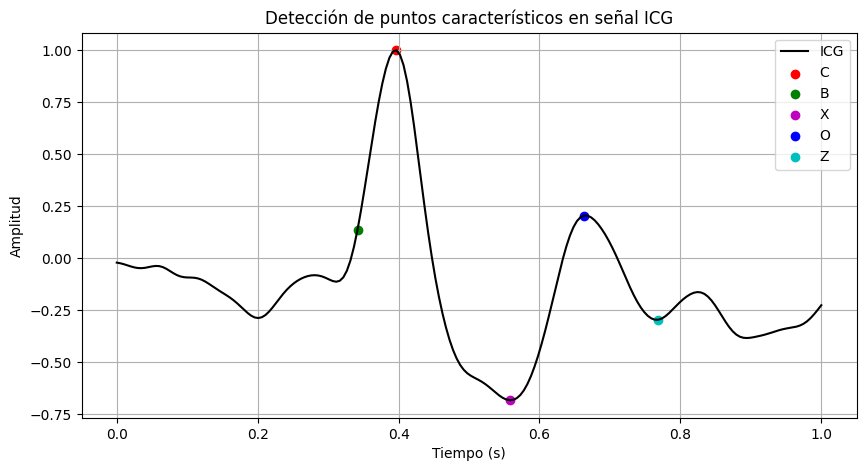

In [ ]:
import numpy as np
import scipy.signal as signal
from scipy.signal import find_peaks, savgol_filter, argrelextrema
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt

# ===================== #
#    1. FUNCIONES       #
# ===================== #

def relative_energy(signal, fs, long_win=0.95, short_win=0.14):
    long_len = int(long_win * fs)
    short_len = int(short_win * fs)
    Xre = np.zeros_like(signal)
    for n in range(len(signal)):
        i1, i2 = max(0, n - long_len // 2), min(len(signal), n + long_len // 2)
        j1, j2 = max(0, n - short_len // 2), min(len(signal), n + short_len // 2)
        long_energy = np.sum(signal[i1:i2] ** 2)
        short_energy = np.sum(signal[j1:j2] ** 2)
        if long_energy != 0:
            Xre[n] = signal[n] * (short_energy / long_energy)
    return Xre


def detect_C_peaks(icg_filtered, fs):
    Xre = relative_energy(icg_filtered, fs)
    sorted_peaks = np.sort(Xre[Xre > np.mean(Xre)])
    maxval = sorted_peaks[-2] if len(sorted_peaks) > 1 else sorted_peaks[-1]
    Thr_max, Thr_min = 0.2 * maxval, 0.02 * maxval

    C_peaks, active = [], False
    for i in range(1, len(Xre)):
        if not active and Xre[i] > Thr_max:
            active, start_idx = True, i
        elif active and Xre[i] < Thr_min:
            end_idx = i
            peak_idx = start_idx + np.argmax(Xre[start_idx:end_idx])
            if not C_peaks or (peak_idx - C_peaks[-1]) > int(0.25 * fs):
                C_peaks.append(peak_idx)
            active = False

    final_C_peaks = []
    for i, p in enumerate(C_peaks):
        if i < 5:
            final_C_peaks.append(p)
        else:
            prev_cc = np.diff(final_C_peaks[-5:])
            avg_cc = np.mean(prev_cc)
            if (p - final_C_peaks[-1]) > 1.7 * avg_cc:
                final_C_peaks.append(p)
    return np.array(final_C_peaks), Xre


def find_B_point(icg_segment, Cpos, fs, Afrac=0.2, Bslope1=0.11, Bslope2=0.08):
    BlimL = max(0, int(Cpos - 0.08 * fs))
    for i in range(Cpos - 1, BlimL, -1):
        if icg_segment[i] <= Afrac * icg_segment[Cpos]:
            BlimR = i
            break
    else:
        BlimR = BlimL
    slope = np.gradient(icg_segment)
    for i in range(BlimR, BlimL, -1):
        if (i > 0 and icg_segment[i] < icg_segment[i-1]) or abs(slope[i]) > Bslope1:
            return i
    for i in range(BlimR, BlimL, -1):
        if abs(slope[i]) > Bslope2:
            return i
    return BlimL + np.argmin(icg_segment[BlimL:BlimR+1])


def detectar_punto_X(icg_segment, C_index, fs, plot=False, suavizar=True):
    # 1. Definir ventana temporal (0.05s a 0.4s después de C)
    CXmin_s, CXmax_s = 0.05, 0.4
    CXmin_samp, CXmax_samp = int(fs * CXmin_s), int(fs * CXmax_s)
    start = max(int(C_index + CXmin_samp), 0)
    end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)
    ventana = icg_segment[start:end]

    if len(ventana) < 3:
        return {"caso": "ninguno", "mensaje": "Ventana demasiado corta"}

    # 2. Suavizar señal si está activado
    if suavizar:
        ventana = gaussian_filter1d(ventana, sigma=1)

    # 3. Detectar mínimos locales
    min_indices = argrelextrema(ventana, np.less)[0]
    if len(min_indices) == 0:
        return {"caso": "ninguno", "mensaje": "No se detectaron mínimos locales"}

    # 4. Detectar mínimo global
    abs_min_idx = np.argmin(ventana)

    # 5. Clasificación según mínimos detectados
    if len(min_indices) == 1:
        idx = min_indices[0]
        if idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) == 2:
        X1_idx, X2_idx = min_indices[0], min_indices[1]
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        umbral = 0.05
        idx = min_indices[0]
        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X1_idx] > ventana[X2_idx]:
            resultado = {"caso": "X", "X": X2_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    else:
        X1_idx, X2_idx, X3_idx = min_indices[:3]
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        umbral = 0.05
        idx = min_indices[0]
        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X3_idx] < ventana[X2_idx]:
            resultado = {"caso": "X", "X": X3_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    # Ajuste de índices absolutos
    if resultado["caso"] == "X":
        resultado["X"] += start
    elif resultado["caso"] == "X1":
        resultado["X1"] += start
    elif resultado["caso"] == "X1_X2":
        resultado["X1"] += start
        resultado["X2"] += start

    return resultado


def detect_O_point(segment, C_index, fs):
    start_search = C_index + int(0.2 * fs)
    end_search = min(C_index + int(0.5 * fs), len(segment))
    search_region = segment[start_search:end_search]
    if len(search_region) == 0:
        return None
    peaks, _ = signal.find_peaks(search_region)
    if len(peaks) == 0:
        return None
    max_peak_idx = peaks[np.argmax(search_region[peaks])]
    return start_search + max_peak_idx


def detect_Z_point(segment, O_index, fs):
    # Define search window (start just after O, up to 0.1s after)
    start_search = O_index + int(0.005 * fs)
    end_search = O_index + int(0.15 * fs)
    end_search = min(end_search, len(segment))

    # Extract search region
    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None

    # Invert the signal to find local minima as peaks
    inverted_region = -search_region
    peaks, _ = signal.find_peaks(inverted_region)

    if len(peaks) == 0:
        return None  # No local minima found

    # Choose the first local minimum
    Z_index = start_search + peaks[0]
    return Z_index


def detectar_punto_Y(icg_segment, resultado_X, O_index, fs):
    # Selección del índice de X
    if resultado_X["caso"] == "X":
        X_idx = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        X_idx = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        X_idx = resultado_X["X2"]
    else:
        return None

    if X_idx >= O_index:
        return None

    # Definir ventana temporal tras X
    min_offset = int(0.06 * fs)  # 60 ms
    max_offset = O_index
    inicio = X_idx + min_offset
    fin = min(X_idx + max_offset, O_index + 1)

    if fin <= inicio or fin > len(icg_segment):
        return None

    ventana_Y = icg_segment[inicio:fin]

    # Detectar mínimos locales
    min_idx = argrelextrema(ventana_Y, np.less)[0]

    for idx in min_idx:
        # Verificar que la curva baja antes y sube después (mínimo local "válido")
        if 1 <= idx < len(ventana_Y) - 1:
            if ventana_Y[idx - 1] > ventana_Y[idx] < ventana_Y[idx + 1]:
                return inicio + idx

    # Si no hay mínimos válidos con esa forma
    return None
# ===================== #
#     2. CARGA & PLOT   #
# ===================== #

fs = 200
segmento_idx = 1000
segmento = v_segments['icg_segment'].iloc[segmento_idx]

# Detectar todos los puntos
C_peaks, _ = detect_C_peaks(segmento, fs)
B_points = find_B_point(segmento, C_peaks[0], fs)
X_result = detectar_punto_X(segmento, C_peaks[0], fs)
O_point = detect_O_point(segmento, C_peaks[0], fs)
Z_point = detect_Z_point(segmento, O_point, fs)
Y_point = detectar_punto_Y(segmento, X_result, O_point, fs)

def plot_icg_with_points(icg_segment, fs,
                         C_idx, B_idxs, X_res, O_idx, Z_idx, Y_idx):
    time = np.linspace(0, len(icg_segment)/fs, len(icg_segment))
    plt.figure(figsize=(10,5))
    plt.plot(time, icg_segment, color='k', label='ICG')

    plt.scatter(time[C_idx], icg_segment[C_idx], color='r', label='C')
    plt.scatter(time[B_idxs], icg_segment[B_idxs], color='g', label='B')


    if X_res['caso']=='X':
        plt.scatter(time[X_res['X']], icg_segment[X_res['X']], color='m', label='X')
    elif X_res['caso']=='X1':
        plt.scatter(time[X_res['X1']], icg_segment[X_res['X1']], color='m', label='X1')
    elif X_res['caso']=='X1_X2':
        plt.scatter(time[X_res['X1']], icg_segment[X_res['X1']], color='m', label='X1')
        plt.scatter(time[X_res['X2']], icg_segment[X_res['X2']], color='y', label='X2')

    if O_idx is not None:
        plt.scatter(time[O_idx], icg_segment[O_idx], color='b', label='O')

    if Z_idx is not None:
        plt.scatter(time[Z_idx], icg_segment[Z_idx], color='c', label='Z')

    if Y_idx is not None:
        plt.scatter(time[Y_idx], icg_segment[Y_idx], color='orange', label='Y')

    plt.legend()
    plt.title('Detección de puntos característicos en señal ICG')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid(True)
    plt.show()

# Llamada al plot
plot_icg_with_points(segmento, fs, C_peaks[0], B_points, X_result, O_point, Z_point, Y_point)


###Aplicación algoritmos no supervisados de clustering

###K-MEDOIDS + DTW

In [ ]:
!pip install pyclustering

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 21.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395100 sha256=226244016299c7eeb81fc70913012edfdf540bfeb8e6d11e3917caa2d219ce7c
  Stored in directory: /root/.cache/pip/wheels/9f/99/15/e881f46a92690ae77c2e3b255b89ea45d3a867b1b6c2ab3ba9
Successfully built pyclustering


In [ ]:
pip install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 5.5 MB/s eta 0:00:00



K = 2

K = 3

K = 4

K = 5

K = 6

🔍 Silhouette → Mejor K: 6 (valor: 0.2203)


<ipython-input-37-48cf6a0aa945>:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v_segments_sample[f'Cluster_{metric}'] = labels  # Añadir etiquetas correctas al DataFrame
<ipython-input-37-48cf6a0aa945>:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v_segments_sample[f'Cluster_{metric}'] = labels  # Añadir etiquetas correctas al DataFrame


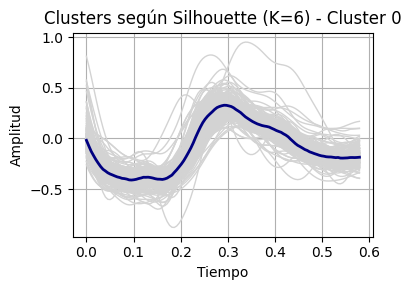

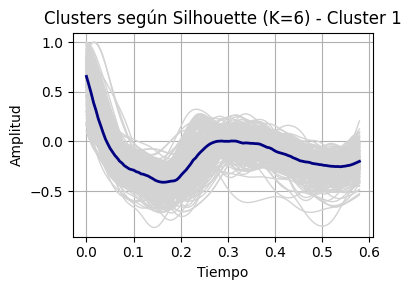

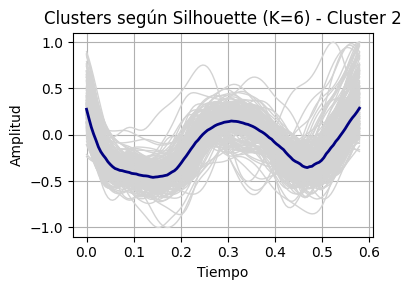

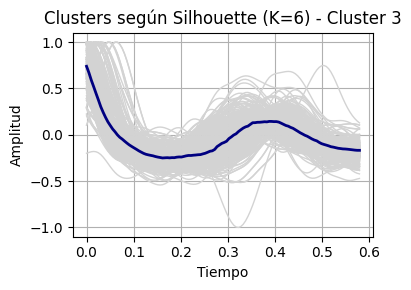

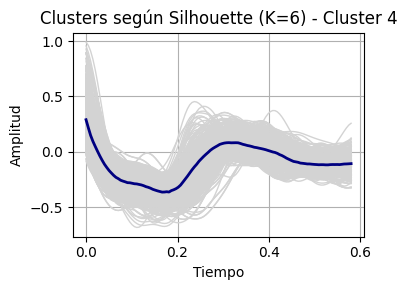

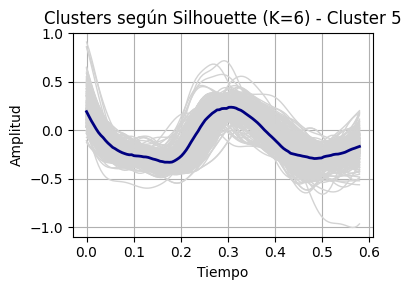


🔍 DaviesBouldin → Mejor K: 6 (valor: 1.7963)


<ipython-input-37-48cf6a0aa945>:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v_segments_sample[f'Cluster_{metric}'] = labels  # Añadir etiquetas correctas al DataFrame


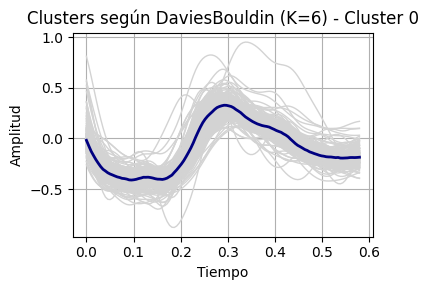

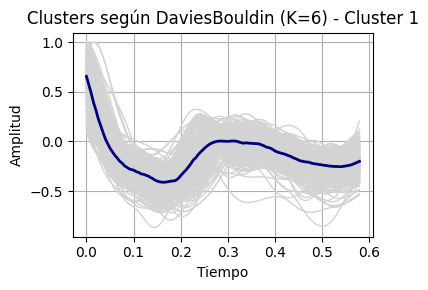

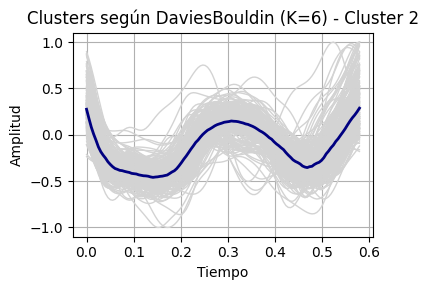

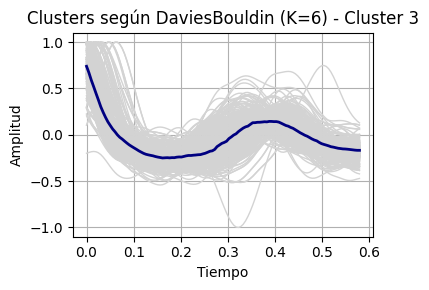

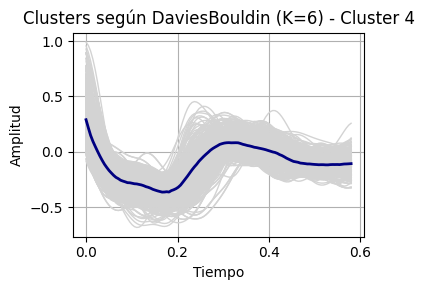

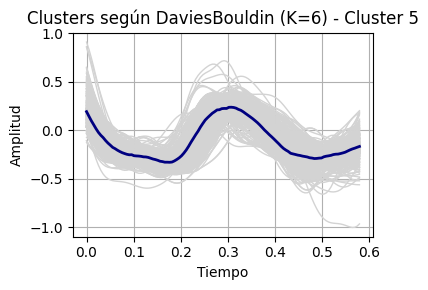


🔍 CalinskiHarabasz → Mejor K: 2 (valor: 331.5277)


<ipython-input-37-48cf6a0aa945>:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v_segments_sample[f'Cluster_{metric}'] = labels  # Añadir etiquetas correctas al DataFrame


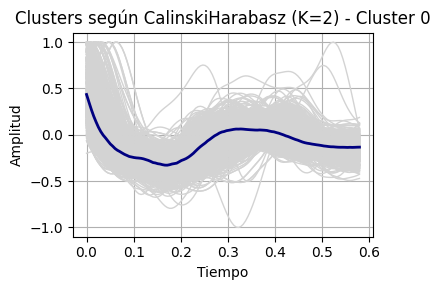

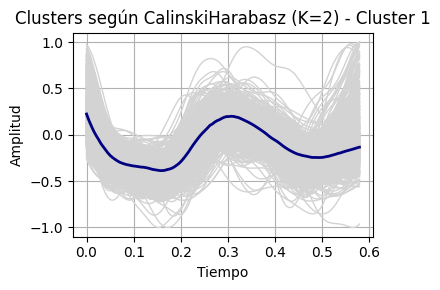


🔍 Dunn → Mejor K: 3 (valor: 0.0333)


<ipython-input-37-48cf6a0aa945>:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v_segments_sample[f'Cluster_{metric}'] = labels  # Añadir etiquetas correctas al DataFrame


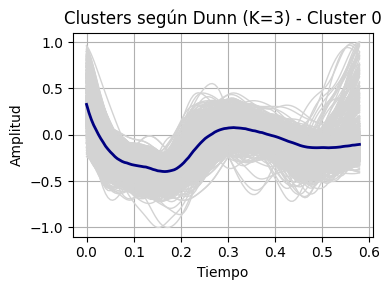

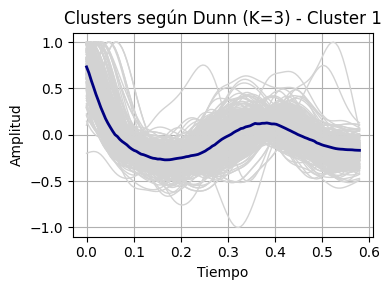

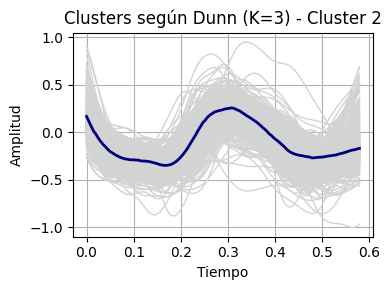

In [ ]:
import numpy as np
import pandas as pd
from pyclustering.cluster.kmedoids import kmedoids
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from tslearn.metrics import cdist_dtw
import matplotlib.pyplot as plt
import random
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# Dunn Index
def dunn_index(X, labels):
    unique_labels = np.unique(labels)
    inter_cluster = []
    intra_cluster = []

    for i in unique_labels:
        cluster_i = X[labels == i]
        if len(cluster_i) < 2:
            intra_cluster.append(0)
        else:
            intra = np.max(pdist(cluster_i))
            intra_cluster.append(intra)

    for i, j in combinations(unique_labels, 2):
        cluster_i = X[labels == i]
        cluster_j = X[labels == j]
        dist = np.min([np.linalg.norm(x - y) for x in cluster_i for y in cluster_j])
        inter_cluster.append(dist)

    return np.min(inter_cluster) / np.max(intra_cluster)


# === 1. Selección de muestra y matriz DTW ===
v_segments_sample = v_segments['Segment_partial'] #al contrario que en la anterior BBDD, aquí se cogen todos los segmentos ya que hay un total
#de 1800
X = np.stack(v_segments_sample.values)
dtw_distances = cdist_dtw(X, global_constraint="sakoe_chiba", sakoe_chiba_radius=int(0.1 * X.shape[1]))

range_k = range(2, 7)
results = []

for k in range_k:
    print(f"\nK = {k}")
    initial_medoids = random.sample(range(len(X)), k)
    kmed = kmedoids(dtw_distances.tolist(), initial_medoids, data_type='distance_matrix')
    kmed.process()
    clusters = kmed.get_clusters()

    labels = np.empty(len(X), dtype=int)
    for idx, points in enumerate(clusters):
        labels[points] = idx

    silhouette = silhouette_score(dtw_distances, labels, metric='precomputed')
    davies = davies_bouldin_score(X, labels)
    calinski = calinski_harabasz_score(X, labels)
    dunn = dunn_index(X, labels)

    results.append({
        'K': k,
        'Silhouette': silhouette,
        'DaviesBouldin': davies,
        'CalinskiHarabasz': calinski,
        'Dunn': dunn,
        'Labels': labels.copy()
    })

# === 2. Elegir mejor K según cada métrica ===
df_results = pd.DataFrame(results)

best_by = {
    'Silhouette': df_results.loc[df_results['Silhouette'].idxmax()],
    'DaviesBouldin': df_results.loc[df_results['DaviesBouldin'].idxmin()],
    'CalinskiHarabasz': df_results.loc[df_results['CalinskiHarabasz'].idxmax()],
    'Dunn': df_results.loc[df_results['Dunn'].idxmax()]
}

# === 3. Plot por cada K óptimo según métrica ===
t = np.arange(X.shape[1]) / FS
for metric, res in best_by.items():
    print(f"\n🔍 {metric} → Mejor K: {res['K']} (valor: {res[metric]:.4f})")
    labels = res['Labels']
    v_segments_sample[f'Cluster_{metric}'] = labels  # Añadir etiquetas correctas al DataFrame


    for cluster_id in np.unique(labels):
        cluster_indices = np.where(labels == cluster_id)[0]
        cluster_segments = X[cluster_indices]

        # Calcular el segmento mediana
        representative_segment = np.median(cluster_segments, axis=0)

        # Crear figura
        plt.figure(figsize=(4, 3))

        # Dibujar todos los segmentos del cluster en gris claro
        for segment in cluster_segments:
            plt.plot(t, segment, color='lightgray', linewidth=1)

        # Dibujar el segmento representativo en azul oscuro
        plt.plot(t, representative_segment, color='navy', linewidth=2)

        plt.title(f'Clusters según {metric} (K={int(res["K"])}) - Cluster {cluster_id}')
        plt.xlabel("Tiempo")
        plt.ylabel("Amplitud")
        plt.grid(True)
        plt.tight_layout()
        plt.show()


In [ ]:
!pip install kneed

Calculando matriz de distancias DTW...
Probando diferentes valores de K...
 - Clustering con K = 2
   → Distancia promedio intra-cluster: 1.3925


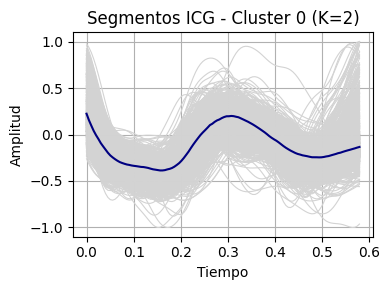

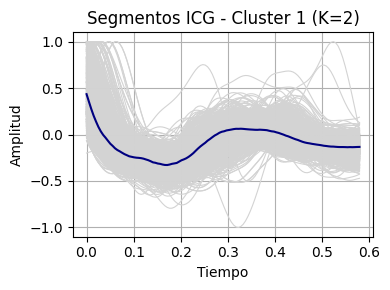

 - Clustering con K = 3
   → Distancia promedio intra-cluster: 1.3313


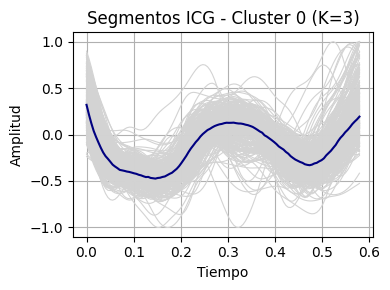

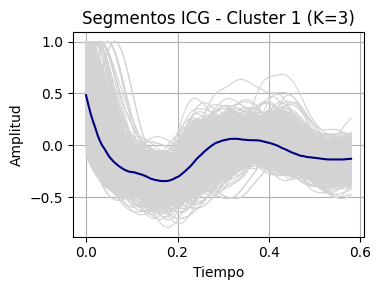

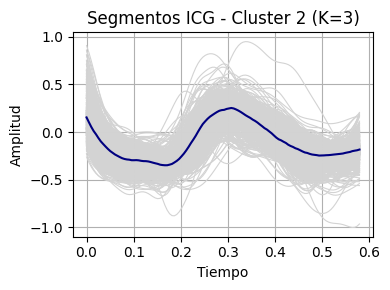

 - Clustering con K = 4
   → Distancia promedio intra-cluster: 1.2354


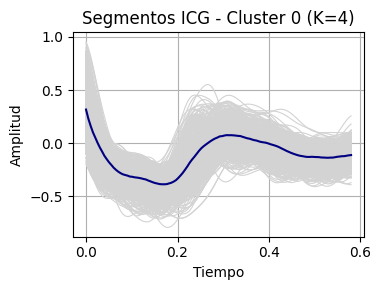

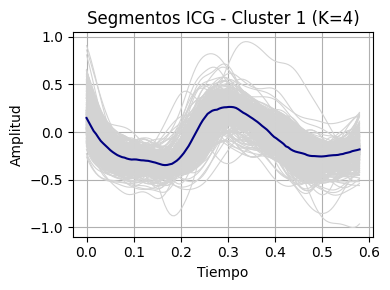

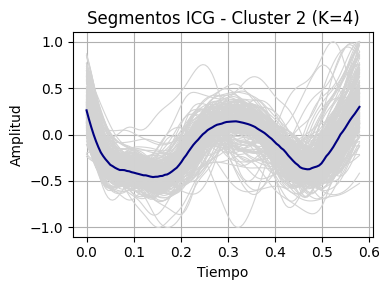

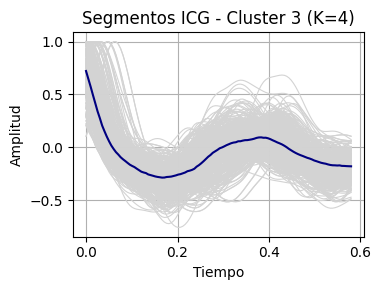

 - Clustering con K = 5
   → Distancia promedio intra-cluster: 1.1088


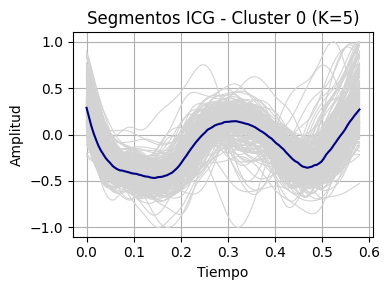

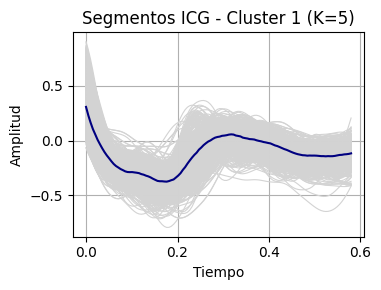

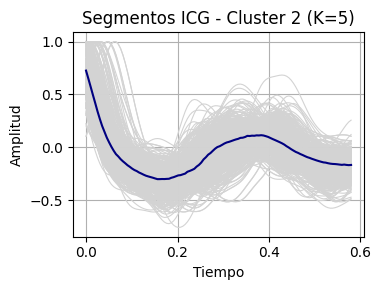

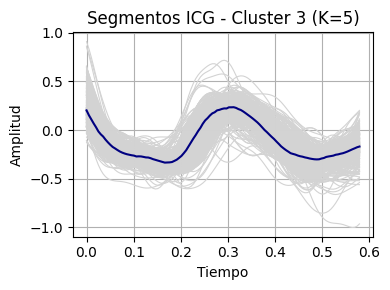

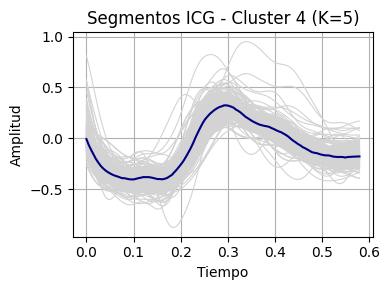

 - Clustering con K = 6
   → Distancia promedio intra-cluster: 1.0569


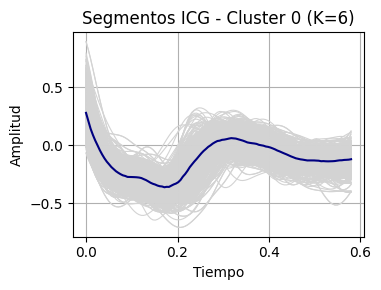

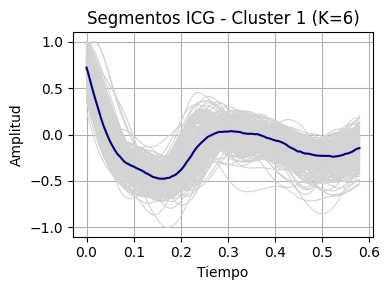

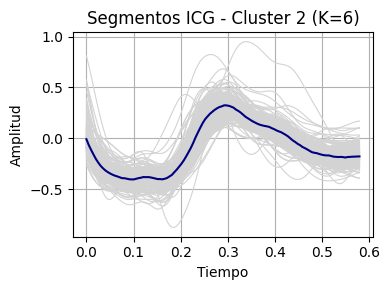

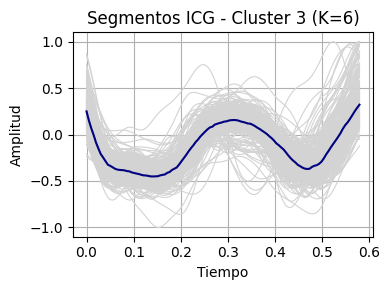

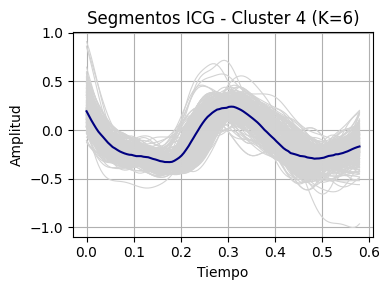

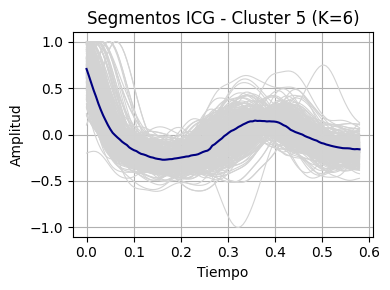

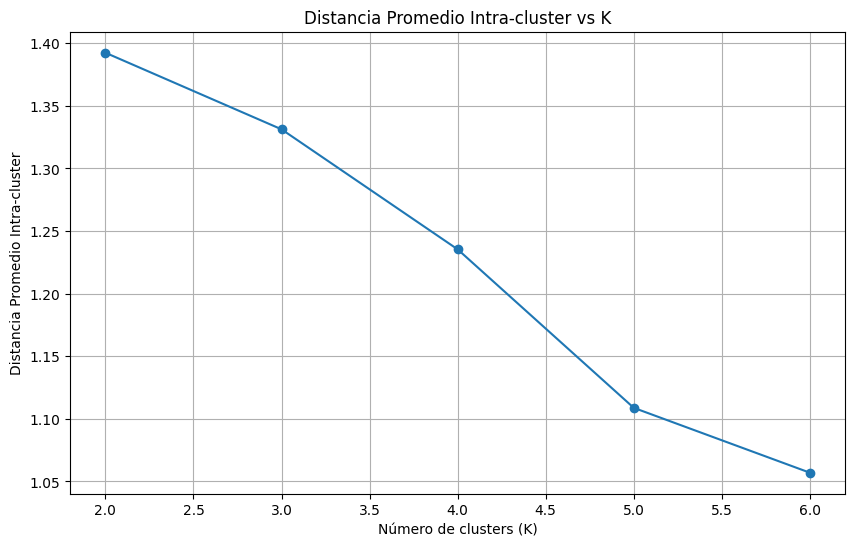

In [ ]:
import numpy as np
from pyclustering.cluster.kmedoids import kmedoids
from tslearn.metrics import cdist_dtw
import matplotlib.pyplot as plt
import random

# 1. Segmentos
v_segments_sample = v_segments['Segment_partial']
#.sample(n=1000, random_state=42).reset_index(drop=True)

# Extraer la matriz de segmentos de la muestra
X = np.stack(v_segments_sample.values)

# 2. Calcular la matriz de distancias DTW
print("Calculando matriz de distancias DTW...")
window_size = int(0.1 * X.shape[1])
dtw_distances = cdist_dtw(X, global_constraint="sakoe_chiba", sakoe_chiba_radius=window_size)

# 3. Función para calcular distancia promedio intra-cluster
def intra_cluster_distance(k, labels, dtw_distances):
    intra_cluster_distances = []

    for cluster_id in range(k):
        cluster_points = np.where(labels == cluster_id)[0]
        if len(cluster_points) > 1:
            # Calcular la distancia promedio entre todos los pares de segmentos dentro del cluster
            distances = dtw_distances[cluster_points[:, None], cluster_points]
            intra_cluster_distances.append(np.mean(distances))  # Promedio de las distancias DTW dentro del cluster
        else:
            intra_cluster_distances.append(0)  # Si solo hay un elemento en el cluster, la distancia es 0

    return np.mean(intra_cluster_distances)  # Promedio de todas las distancias intra-cluster para este K

# 4. Probar distintos valores de K (2 a 6)
intra_cluster_distances_per_k = {}

print("Probando diferentes valores de K...")
for k in range(2, 7):
    print(f" - Clustering con K = {k}")

    # Elegir k índices aleatorios como medoids iniciales
    initial_medoids = random.sample(range(len(X)), k)

    # Crear e inicializar el algoritmo con matriz de distancias
    kmedoids_instance = kmedoids(dtw_distances.tolist(), initial_medoids, data_type='distance_matrix')

    # Ejecutar el clustering
    kmedoids_instance.process()

    # Obtener los clusters
    clusters = kmedoids_instance.get_clusters()

    # Crear array de etiquetas
    labels = np.empty(len(X), dtype=int)
    for cluster_id, cluster_points in enumerate(clusters):
        labels[cluster_points] = cluster_id

    # Evaluar la distancia promedio intra-cluster
    mean_intra_cluster_distance = intra_cluster_distance(k, labels, dtw_distances)
    intra_cluster_distances_per_k[k] = mean_intra_cluster_distance
    print(f"   → Distancia promedio intra-cluster: {mean_intra_cluster_distance:.4f}")

    # Crear los plots de los clusters con mejoras visuales
    t = np.arange(X.shape[1]) / FS
    for cluster_id in range(k):
        cluster_segments = X[labels == cluster_id]

        if cluster_segments.shape[0] == 0:
            continue  # Evitar clusters vacíos

        # Calcular el segmento representativo como la mediana punto a punto
        representative_segment = np.median(cluster_segments, axis=0)

        plt.figure(figsize=(4, 3))

        # Dibujar todos los segmentos en gris claro
        for segment in cluster_segments:
            plt.plot(t, segment, color='lightgray', linewidth=0.8)

        # Dibujar el segmento representativo en azul oscuro
        plt.plot(t, representative_segment, color='navy', linewidth=1.5)

        plt.title(f'Segmentos ICG - Cluster {cluster_id} (K={k})')
        plt.xlabel('Tiempo')
        plt.ylabel('Amplitud')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Mostrar las distancias intra-cluster para cada K
plt.figure(figsize=(10, 6))
plt.plot(list(intra_cluster_distances_per_k.keys()), list(intra_cluster_distances_per_k.values()), marker='o')
plt.title('Distancia Promedio Intra-cluster vs K')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Distancia Promedio Intra-cluster')
plt.grid(True)
plt.show()


In [ ]:
#Se aplica la técnica del codo para hallar K óptimo.
from kneed import KneeLocator

# Detectar punto del codo ignorando el primer salto (1 -> 2). Esto se hace porque si K se obtiene por caída más brusca evidentemente se obtiene
# que es en k=2 mientras que este puede no ser el valor óptimo.

# Extraer los valores de K y sus distancias intra-cluster
Ks = np.array(list(intra_cluster_distances_per_k.keys()))
distances = np.array(list(intra_cluster_distances_per_k.values()))

# Aplicar método del codo, ignorando el primer salto para evitar que devuelva K=2 por defecto
#kneedle = KneeLocator(Ks, distances, curve='convex', direction='decreasing')

if kneedle.knee is not None:
    optimal_k = kneedle.knee
    print(f"\n✅ K óptimo detectado automáticamente con método del codo: K = {optimal_k}")
else:
    # Si no se detecta un codo claro, seleccionamos el mayor descenso RELATIVO excluyendo el primero
    relative_diffs = np.diff(distances) / distances[:-1]  # cambios relativos
    best_index = np.argmin(relative_diffs[1:]) + 1  # +1 porque ignoramos salto K=2
    optimal_k = Ks[best_index]
    print(f"\n⚠️ No se detectó un codo claro. Se selecciona K = {optimal_k} como el de mayor descenso relativo tras K=2.")

# Si quieres guardar este K óptimo para luego usarlo:
k_optimo = optimal_k

import pandas as pd

# Volver a aplicar clustering sobre la muestra con el K óptimo
print(f"\n🔁 Aplicando clustering final con K = {optimal_k}...")
initial_medoids = random.sample(range(len(X)), optimal_k)
final_kmedoids = kmedoids(dtw_distances.tolist(), initial_medoids, data_type='distance_matrix')
final_kmedoids.process()
final_clusters = final_kmedoids.get_clusters()

# Crear etiquetas finales
final_labels = np.empty(len(X), dtype=int)
for cluster_id, cluster_points in enumerate(final_clusters):
    final_labels[cluster_points] = cluster_id

# Crear tabla de clusters con los segmentos completos
cluster_table = pd.DataFrame(columns=[f'Cluster_{i}' for i in range(optimal_k)])

# Importante: obtener los índices originales de los segmentos muestreados
original_indices = v_segments.index

# Asignar los segmentos completos a la tabla por cluster
for i, label in enumerate(final_labels):
    idx = original_indices[i]  # Índice en el DataFrame original
    full_segment = v_segments.loc[idx, 'icg_segment']
    row = [None] * optimal_k
    row[label] = full_segment
    cluster_table.loc[len(cluster_table)] = row

# Mostrar resumen
print(f"✅ Tabla de segmentos agrupados por cluster generada con {len(cluster_table)} filas.")
print(cluster_table.head())

# Guardar tabla en CSV
cluster_table.to_csv('tabla_clusters_segmentos_completos.csv', index=False)



✅ K óptimo detectado automáticamente con método del codo: K = 2

🔁 Aplicando clustering final con K = 2...
✅ Tabla de segmentos agrupados por cluster generada con 1946 filas.
  Cluster_0                                          Cluster_1
0      None  [-0.0879120428378609, -0.0978801295061101, -0....
1      None  [-0.06942069528769894, -0.07176496233766803, -...
2      None  [-0.059054204545974404, -0.06793791125007255, ...
3      None  [-0.016860400336395357, -0.024696119334679554,...
4      None  [-0.11504064068538182, -0.12164844524542653, -...


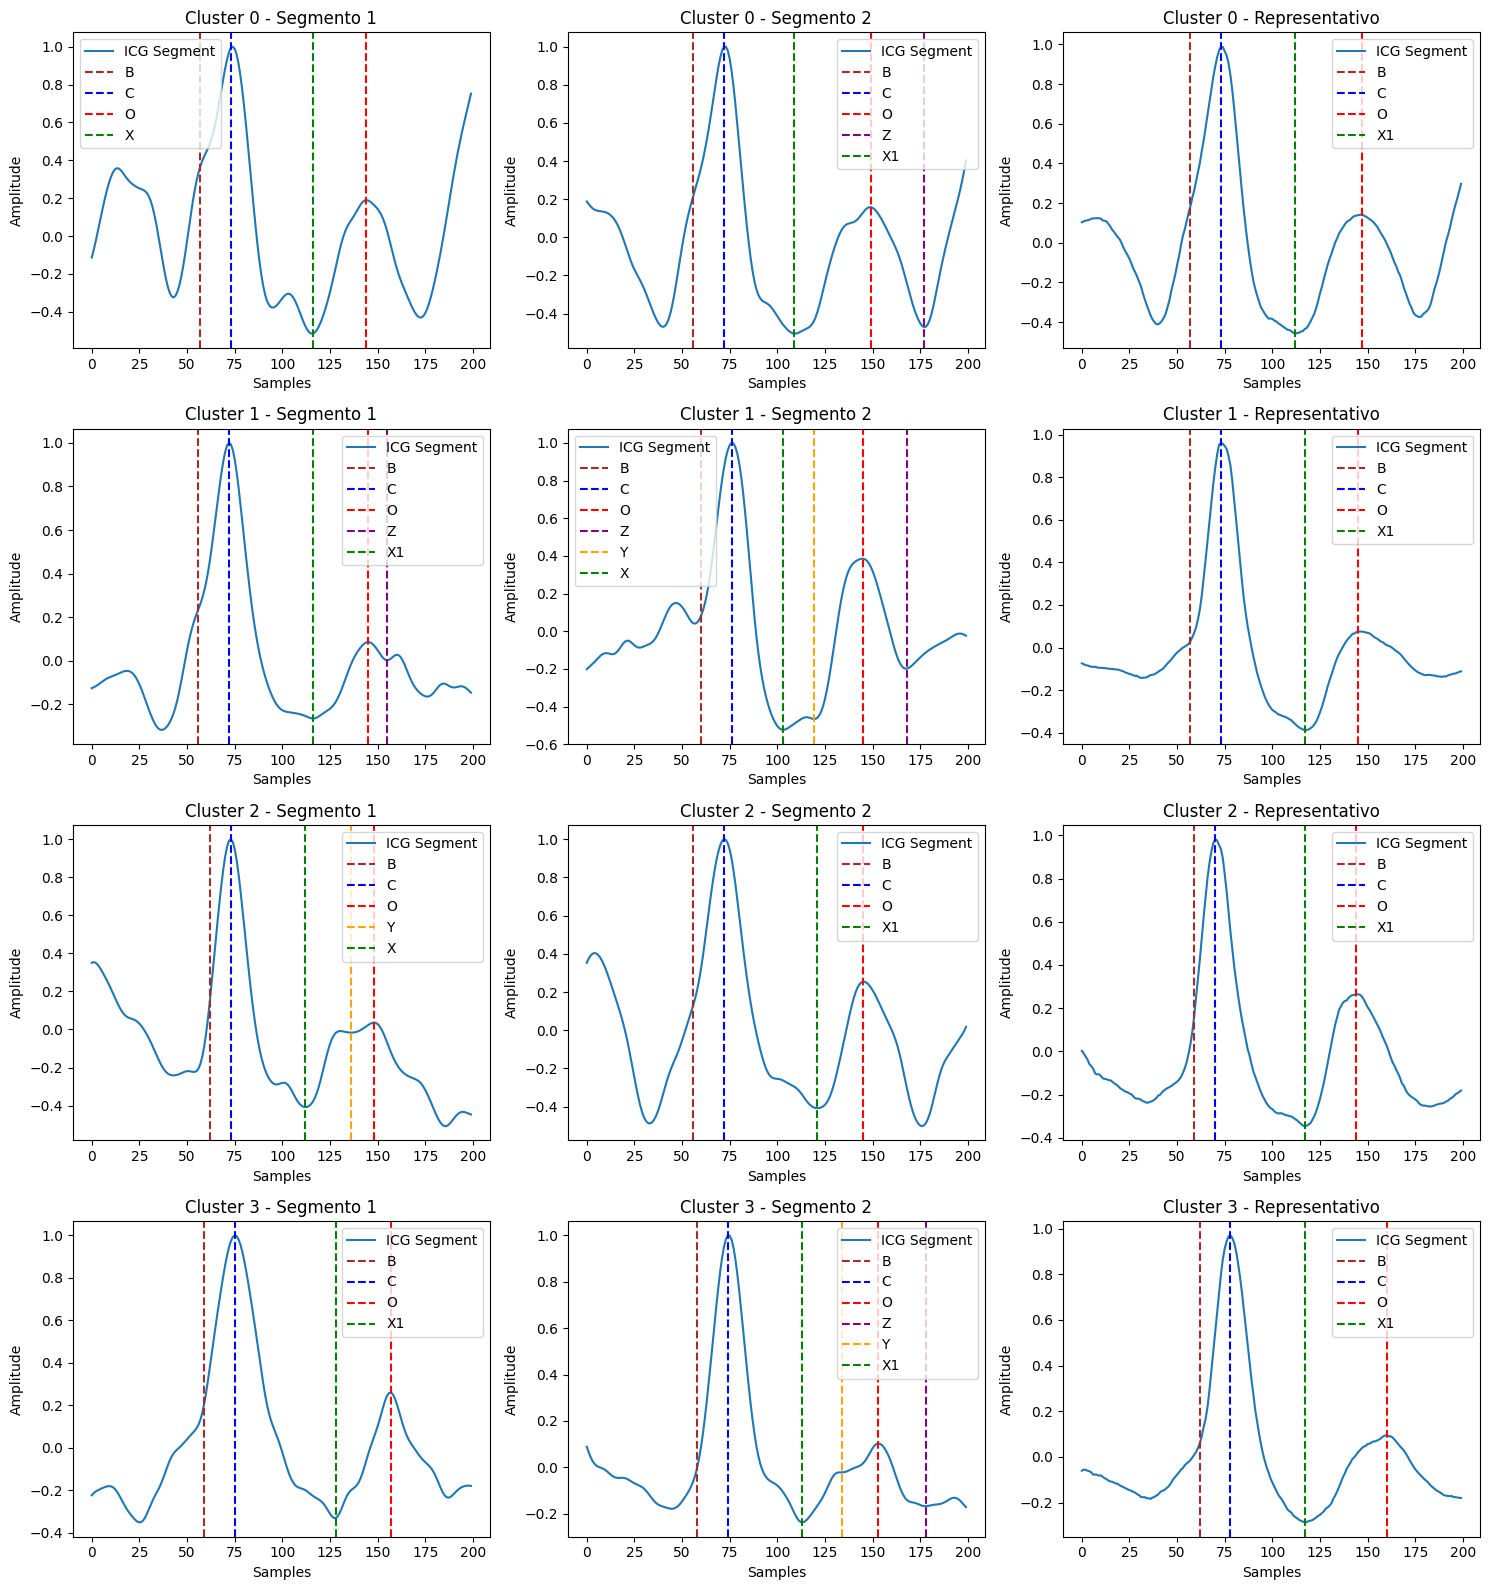

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

N = 2  # Número de segmentos a visualizar por cluster
fs = 200  # Frecuencia de muestreo

def plot_segment_with_points(ax, segment, points, title=""):
    ax.plot(segment, label='ICG Segment')
    colors = {
        "B": "brown", "C": "blue", "X": "green", "X1": "green", "X2": "lime",
        "O": "red", "Z": "purple", "Y": "orange"
    }
    for label, index in points.items():
        if index is not None:
            ax.axvline(index, color=colors.get(label, 'black'), linestyle='--', label=label)
    ax.legend()
    ax.set_title(title)
    ax.set_xlabel('Samples')
    ax.set_ylabel('Amplitude')

def calculate_median_segment(segments):
    min_len = min(len(s) for s in segments)
    stacked = np.stack([s[:min_len] for s in segments])
    return np.median(stacked, axis=0)

num_clusters = k_optimo
fig, axes = plt.subplots(num_clusters, N + 1, figsize=(5 * (N + 1), 4 * num_clusters))

for cluster_id in range(num_clusters):
    # Extraer todos los segmentos del cluster actual, eliminando valores nulos
    segments = cluster_table[f'Cluster_{cluster_id}'].dropna().tolist()

    if len(segments) == 0:
        print(f"⚠️ Cluster {cluster_id} vacío.")
        continue

    # Seleccionar N segmentos aleatorios
    selected_segments = random.sample(segments, min(N, len(segments)))

    # Calcular el segmento representativo
    representative_segment = calculate_median_segment(segments)

    # Detectar puntos característicos en el segmento representativo
    C_peaks, _ = detect_C_peaks(representative_segment, fs)
    if len(C_peaks) == 0:
        print(f"⚠️ Cluster {cluster_id}: no se detectó pico C en el segmento representativo.")
        continue
    C_index = C_peaks[0]
    B_index = find_B_point(representative_segment, C_index, fs)
    resultado_X = detectar_punto_X(representative_segment, C_index, fs)
    O_index = detect_O_point(representative_segment, C_index, fs)
    Z_index = detect_Z_point(representative_segment, O_index, fs) if O_index else None
    Y_index = detectar_punto_Y(representative_segment, resultado_X, O_index, fs)

    puntos_repr = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
    if resultado_X["caso"] == "X":
        puntos_repr["X"] = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        puntos_repr["X1"] = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        puntos_repr["X1"] = resultado_X["X1"]
        puntos_repr["X2"] = resultado_X["X2"]

    # Plot de segmentos individuales
    for i, segment in enumerate(selected_segments):
        C_peaks, _ = detect_C_peaks(segment, fs)
        if len(C_peaks) == 0:
            print(f"⚠️ Segmento en Cluster {cluster_id}: sin pico C.")
            continue
        C_index = C_peaks[0]
        B_index = find_B_point(segment, C_index, fs)
        resultado_X = detectar_punto_X(segment, C_index, fs)
        O_index = detect_O_point(segment, C_index, fs)
        Z_index = detect_Z_point(segment, O_index, fs) if O_index else None
        Y_index = detectar_punto_Y(segment, resultado_X, O_index, fs)

        puntos = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
        if resultado_X["caso"] == "X":
            puntos["X"] = resultado_X["X"]
        elif resultado_X["caso"] == "X1":
            puntos["X1"] = resultado_X["X1"]
        elif resultado_X["caso"] == "X1_X2":
            puntos["X1"] = resultado_X["X1"]
            puntos["X2"] = resultado_X["X2"]

        plot_segment_with_points(axes[cluster_id, i], segment, puntos, title=f"Cluster {cluster_id} - Segmento {i+1}")

    # Plot del segmento representativo
    plot_segment_with_points(axes[cluster_id, N], representative_segment, puntos_repr, title=f"Cluster {cluster_id} - Representativo")

plt.tight_layout()
plt.show()


*Aquí creo que en caso de que el K óptimo que obtenga no sea el que yo considero que es óptimo, lo que he de hacer es crear un código mediante el que para el K que yo le diga, sea capaz de almacenar los segmentos en una tabla distribuída como la del k óptimo: tantas columnas como el k que yo le haya especificado y tantas filas como segmentos almacendaos en el cluster. Esto sería útil para después poder aplicar los algoritmos de delineación de puntos sobre esos clusters almacenados, porque ahora solo se tienen guardados los de k_optimo

In [ ]:
import pandas as pd
import random

# 🔧 Define aquí el K manual deseado
k_manual = 5

print(f"\n🔁 Aplicando clustering manual con K = {k_manual}...")

# Aplica clustering con K manual
initial_medoids_manual = random.sample(range(len(X)), k_manual)
kmedoids_manual = kmedoids(dtw_distances.tolist(), initial_medoids_manual, data_type='distance_matrix')
kmedoids_manual.process()
clusters_manual = kmedoids_manual.get_clusters()

# Crear etiquetas manuales
labels_manual = np.empty(len(X), dtype=int)
for cluster_id, cluster_points in enumerate(clusters_manual):
    labels_manual[cluster_points] = cluster_id

# Crear tabla de clusters con los segmentos completos para K manual
cluster_table_manual = pd.DataFrame(columns=[f'Cluster_{i}' for i in range(k_manual)])

# Índices reales
original_indices = v_segments.index

# Asignar los segmentos completos a la tabla por cluster
for i, label in enumerate(labels_manual):
    idx = original_indices[i]
    full_segment = v_segments.loc[idx, 'icg_segment']
    row = [None] * k_manual
    row[label] = full_segment
    cluster_table_manual.loc[len(cluster_table_manual)] = row

# Mostrar resumen
print(f"✅ Tabla para K = {k_manual} generada con {len(cluster_table_manual)} filas.")
print(cluster_table_manual.head())

# Guardar en CSV con nombre personalizado
cluster_table_manual.to_csv(f'tabla_clusters_segmentos_completos_K{k_manual}.csv', index=False)



🔁 Aplicando clustering manual con K = 5...
✅ Tabla para K = 5 generada con 1946 filas.
  Cluster_0                                          Cluster_1 Cluster_2  \
0      None  [-0.0879120428378609, -0.0978801295061101, -0....      None   
1      None  [-0.06942069528769894, -0.07176496233766803, -...      None   
2      None  [-0.059054204545974404, -0.06793791125007255, ...      None   
3      None  [-0.016860400336395357, -0.024696119334679554,...      None   
4      None  [-0.11504064068538182, -0.12164844524542653, -...      None   

  Cluster_3 Cluster_4  
0      None      None  
1      None      None  
2      None      None  
3      None      None  
4      None      None  


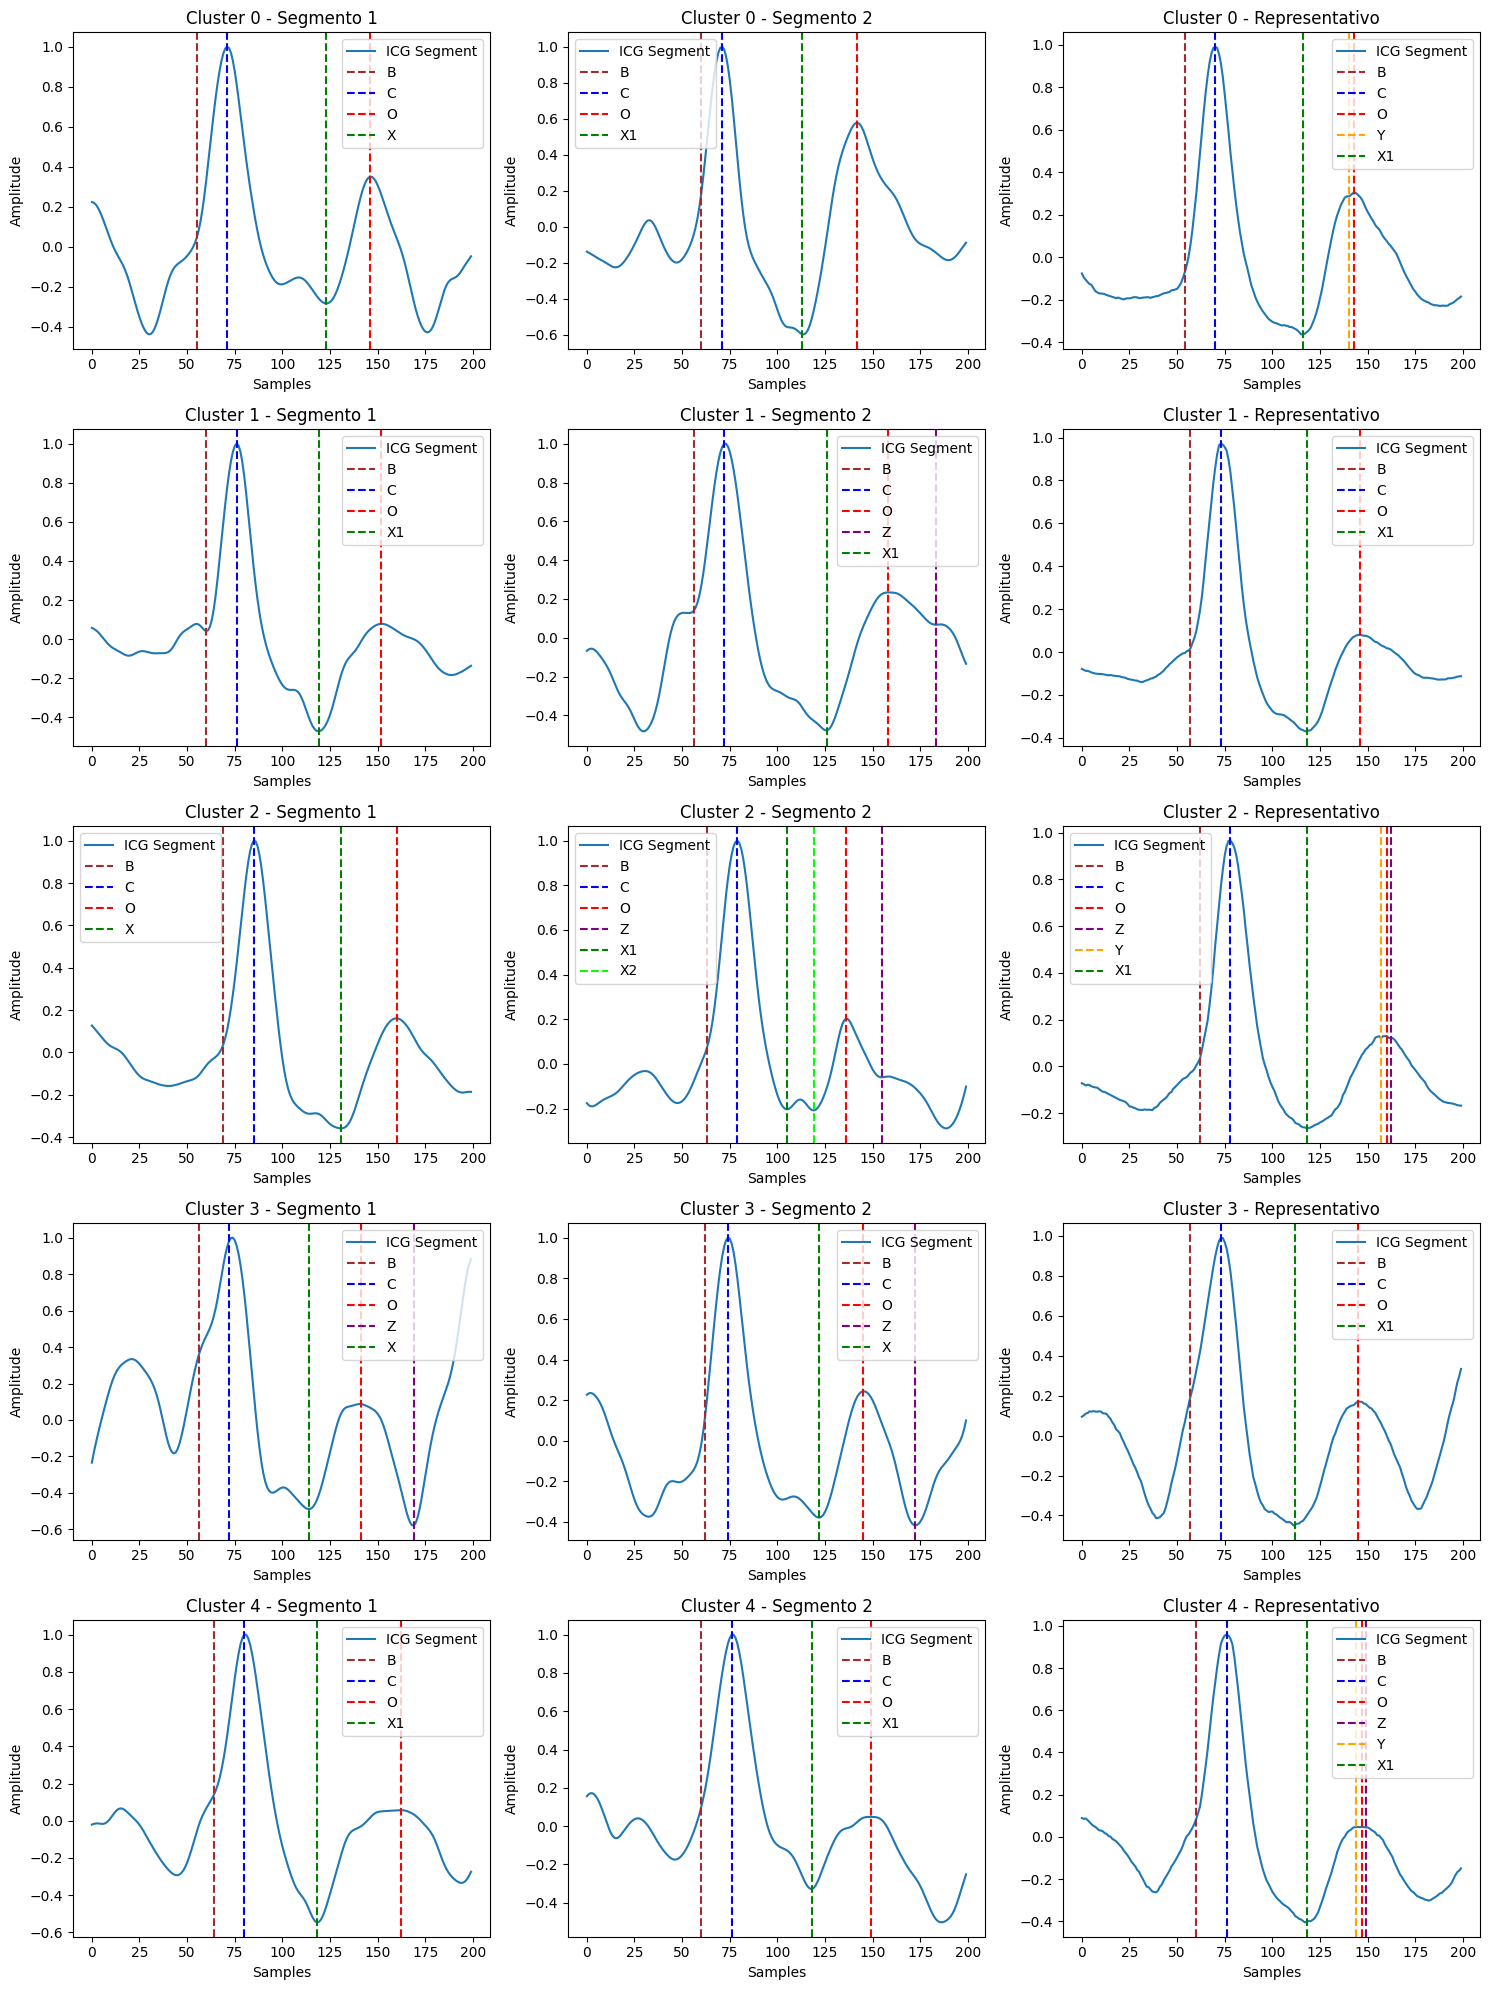

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

N = 2  # Número de segmentos a visualizar por cluster
fs = 200  # Frecuencia de muestreo

def plot_segment_with_points(ax, segment, points, title=""):
    ax.plot(segment, label='ICG Segment')
    colors = {
        "B": "brown", "C": "blue", "X": "green", "X1": "green", "X2": "lime",
        "O": "red", "Z": "purple", "Y": "orange"
    }
    for label, index in points.items():
        if index is not None:
            ax.axvline(index, color=colors.get(label, 'black'), linestyle='--', label=label)
    ax.legend()
    ax.set_title(title)
    ax.set_xlabel('Samples')
    ax.set_ylabel('Amplitude')

def calculate_median_segment(segments):
    min_len = min(len(s) for s in segments)
    stacked = np.stack([s[:min_len] for s in segments])
    return np.median(stacked, axis=0)

num_clusters = k_manual
fig, axes = plt.subplots(num_clusters, N + 1, figsize=(5 * (N + 1), 4 * num_clusters))

for cluster_id in range(num_clusters):
    # Extraer todos los segmentos del cluster actual, eliminando valores nulos
    segments = cluster_table_manual[f'Cluster_{cluster_id}'].dropna().tolist()

    if len(segments) == 0:
        print(f"⚠️ Cluster {cluster_id} vacío.")
        continue

    # Seleccionar N segmentos aleatorios
    selected_segments = random.sample(segments, min(N, len(segments)))

    # Calcular el segmento representativo
    representative_segment = calculate_median_segment(segments)

    # Detectar puntos característicos en el segmento representativo
    C_peaks, _ = detect_C_peaks(representative_segment, fs)
    if len(C_peaks) == 0:
        print(f"⚠️ Cluster {cluster_id}: no se detectó pico C en el segmento representativo.")
        continue
    C_index = C_peaks[0]
    B_index = find_B_point(representative_segment, C_index, fs)
    resultado_X = detectar_punto_X(representative_segment, C_index, fs)
    O_index = detect_O_point(representative_segment, C_index, fs)
    Z_index = detect_Z_point(representative_segment, O_index, fs) if O_index else None
    Y_index = detectar_punto_Y(representative_segment, resultado_X, O_index, fs)

    puntos_repr = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
    if resultado_X["caso"] == "X":
        puntos_repr["X"] = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        puntos_repr["X1"] = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        puntos_repr["X1"] = resultado_X["X1"]
        puntos_repr["X2"] = resultado_X["X2"]

    # Plot de segmentos individuales
    for i, segment in enumerate(selected_segments):
        C_peaks, _ = detect_C_peaks(segment, fs)
        if len(C_peaks) == 0:
            print(f"⚠️ Segmento en Cluster {cluster_id}: sin pico C.")
            continue
        C_index = C_peaks[0]
        B_index = find_B_point(segment, C_index, fs)
        resultado_X = detectar_punto_X(segment, C_index, fs)
        O_index = detect_O_point(segment, C_index, fs)
        Z_index = detect_Z_point(segment, O_index, fs) if O_index else None
        Y_index = detectar_punto_Y(segment, resultado_X, O_index, fs)

        puntos = {"B": B_index, "C": C_index, "O": O_index, "Z": Z_index, "Y": Y_index}
        if resultado_X["caso"] == "X":
            puntos["X"] = resultado_X["X"]
        elif resultado_X["caso"] == "X1":
            puntos["X1"] = resultado_X["X1"]
        elif resultado_X["caso"] == "X1_X2":
            puntos["X1"] = resultado_X["X1"]
            puntos["X2"] = resultado_X["X2"]

        plot_segment_with_points(axes[cluster_id, i], segment, puntos, title=f"Cluster {cluster_id} - Segmento {i+1}")

    # Plot del segmento representativo
    plot_segment_with_points(axes[cluster_id, N], representative_segment, puntos_repr, title=f"Cluster {cluster_id} - Representativo")

plt.tight_layout()
plt.show()


###HDBSCAN + DTW

In [ ]:
!pip install hdbscan

Calculando matriz de distancias DTW...
Aplicando HDBSCAN...
✅ Clusters encontrados: 2
❌ Segmentos marcados como ruido: 388


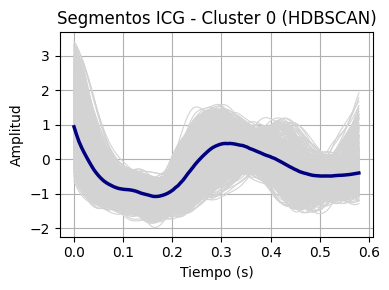

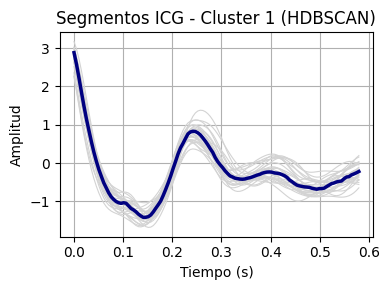

In [ ]:
import numpy as np
import hdbscan
from tslearn.metrics import cdist_dtw
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# 1. Extraer matriz de segmentos
v_segments_sample = v_segments['Segment_partial']
#.sample(n=1000, random_state=42).reset_index(drop=True)
X = np.stack(v_segments_sample.values)
t = np.arange(X.shape[1]) / FS  # vector tiempo en segundos

# 2. Escalado individual
X_scaled = StandardScaler().fit_transform(X)

# 3. Matriz DTW
window_size = int(0.1 * X.shape[1])
print("Calculando matriz de distancias DTW...")
dtw_distances = cdist_dtw(X_scaled, global_constraint="sakoe_chiba", sakoe_chiba_radius=window_size)

# 4. Clustering HDBSCAN
clusterer = hdbscan.HDBSCAN(
    metric='precomputed',
    min_cluster_size=10,
    min_samples=10
)

print("Aplicando HDBSCAN...")
labels = clusterer.fit_predict(dtw_distances)

# 5. Resultados
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print(f"✅ Clusters encontrados: {n_clusters}")
print(f"❌ Segmentos marcados como ruido: {n_noise}")

# 6. Plot por cluster (excluyendo el ruido: label = -1)
for cluster_id in np.unique(labels):
    if cluster_id == -1:
        continue  # ignorar ruido

    cluster_indices = np.where(labels == cluster_id)[0]
    cluster_segments = X[cluster_indices]

    # Calcular señal representativa como la mediana punto a punto
    representative_segment = np.median(cluster_segments, axis=0)

    plt.figure(figsize=(4, 3))

    for segment in cluster_segments:
        plt.plot(t, segment, color='lightgray', linewidth=0.8)

    plt.plot(t, representative_segment, color='navy', linewidth=2.5)
    plt.title(f'Segmentos ICG - Cluster {cluster_id} (HDBSCAN)')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


###Hierarchical clustering (Agglomerative)

In [ ]:
pip install tslearn scipy matplotlib scikit-learn

Calculando matriz de distancias DTW con ventana Sakoe-Chiba...
Realizando clustering jerárquico...


<ipython-input-20-ecd33f473b02>:46: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dtw_distances, method='average')


Evaluando diferentes métricas de calidad para K = 2 a 7...
K=2: Silhouette=0.6427, DBI=1.1038, CH=34.97, Dunn=0.2046
K=3: Silhouette=0.5710, DBI=0.6242, CH=26.87, Dunn=0.2096
K=4: Silhouette=0.3762, DBI=0.8971, CH=165.14, Dunn=0.0774
K=5: Silhouette=0.3342, DBI=1.3142, CH=138.39, Dunn=0.0926
K=6: Silhouette=0.2437, DBI=1.4915, CH=120.00, Dunn=0.0926
K=7: Silhouette=0.2118, DBI=1.4282, CH=102.03, Dunn=0.1057


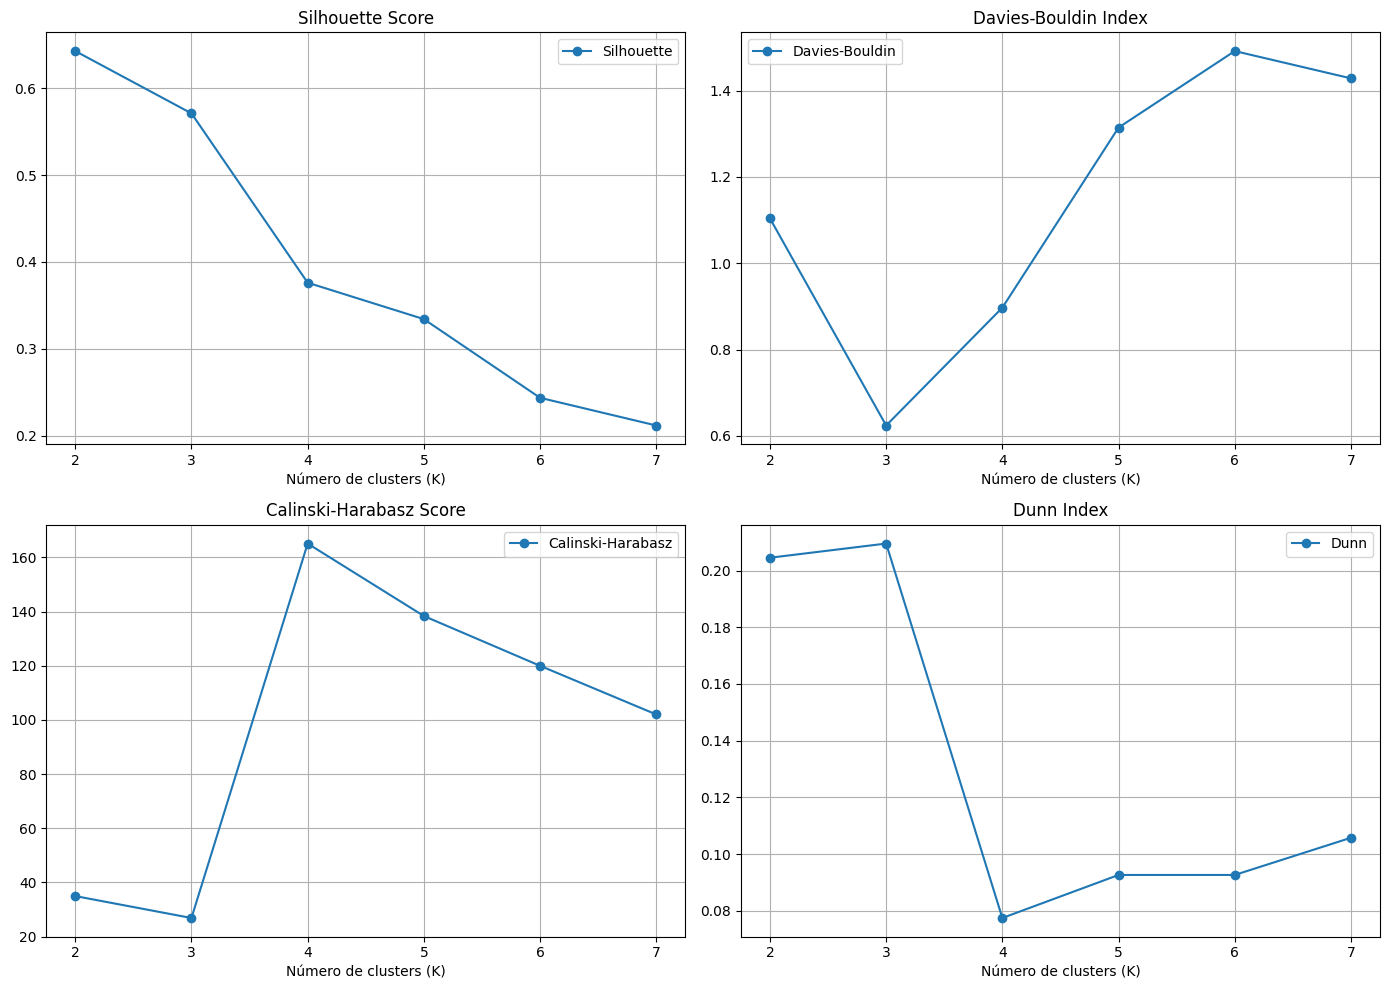


🔹 Silhouette -> K óptimo: 2


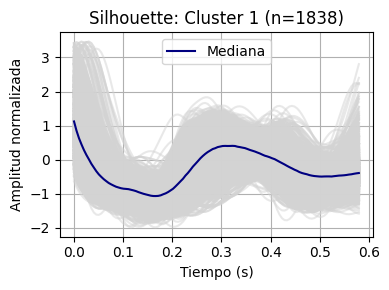

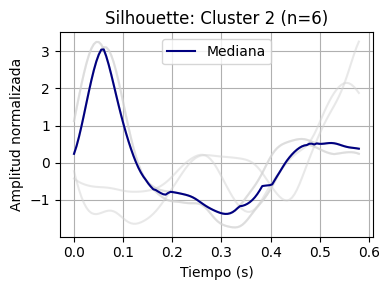


🔹 Davies-Bouldin -> K óptimo: 3


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


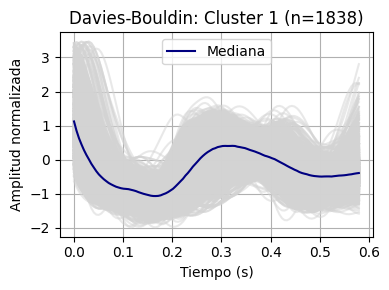

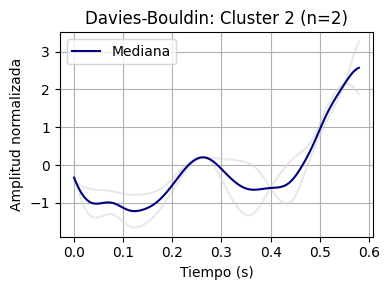

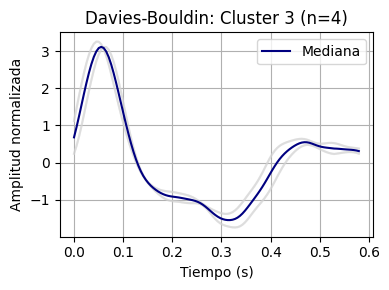


🔹 Calinski-Harabasz -> K óptimo: 4


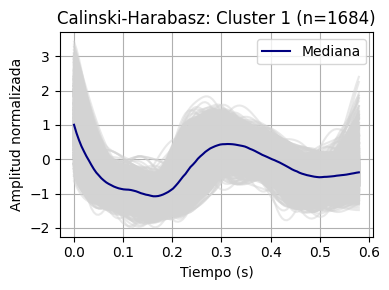

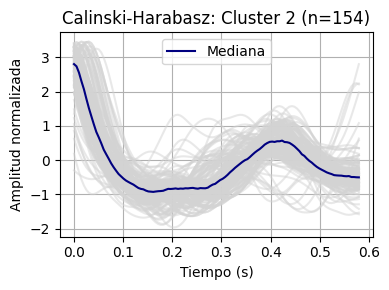

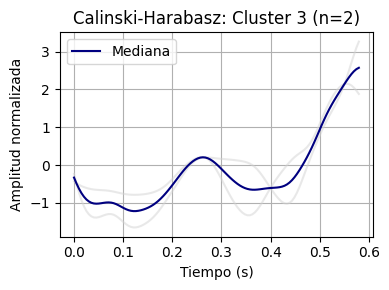

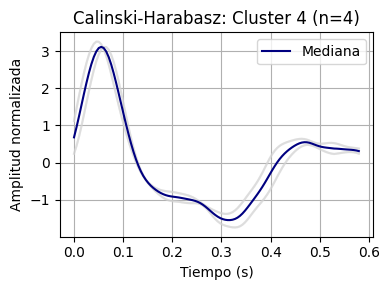


🔹 Dunn -> K óptimo: 3


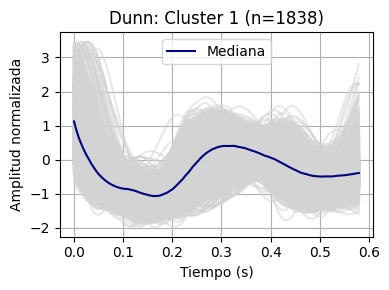

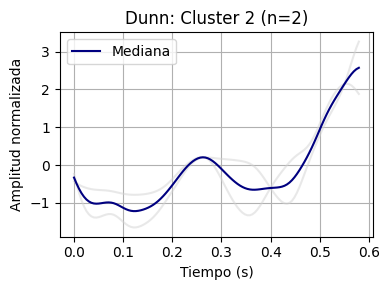

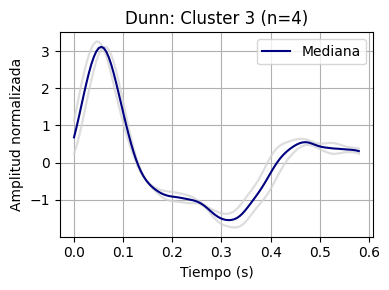

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from tslearn.metrics import cdist_dtw
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.spatial.distance import pdist
from collections import defaultdict


# Dunn Index personalizado
def dunn_index(X, labels):
    unique_clusters = np.unique(labels)
    intra_dists = []
    inter_dists = []

    for i in unique_clusters:
        cluster_i = X[labels == i]
        if len(cluster_i) < 2:
            intra_dists.append(0)
        else:
            intra_dists.append(np.max(pdist(cluster_i)))

        for j in unique_clusters:
            if i < j:
                cluster_j = X[labels == j]
                inter_d = np.min([np.linalg.norm(a - b) for a in cluster_i for b in cluster_j])
                inter_dists.append(inter_d)

    return np.min(inter_dists) / np.max(intra_dists)

# 1. Matriz de segmentos
segment_matrix = np.stack(v_segments['Segment_partial'].values)
#.sample(n=1000, random_state=42).values)

# 2. Matriz de distancias DTW
print("Calculando matriz de distancias DTW con ventana Sakoe-Chiba...")
dtw_distances = cdist_dtw(
    segment_matrix,
    global_constraint="sakoe_chiba",
    sakoe_chiba_radius=int(0.1 * segment_matrix.shape[1])
)

# 3. Clustering jerárquico
print("Realizando clustering jerárquico...")
Z = linkage(dtw_distances, method='average')

# 4. Evaluar múltiples métricas para distintos K
print("Evaluando diferentes métricas de calidad para K = 2 a 7...")
max_k = 7
metrics_table = []

for k in range(2, max_k + 1):
    labels = fcluster(Z, k, criterion='maxclust')

    silhouette = silhouette_score(dtw_distances, labels, metric='precomputed')
    dbi = davies_bouldin_score(segment_matrix, labels)
    ch = calinski_harabasz_score(segment_matrix, labels)
    dunn = dunn_index(segment_matrix, labels)

    metrics_table.append({
        'K': k,
        'Silhouette': silhouette,
        'Davies-Bouldin': dbi,
        'Calinski-Harabasz': ch,
        'Dunn': dunn
    })
    print(f"K={k}: Silhouette={silhouette:.4f}, DBI={dbi:.4f}, CH={ch:.2f}, Dunn={dunn:.4f}")

# 5. Convertir a DataFrame y visualizar métricas
df_metrics = pd.DataFrame(metrics_table)

# 6. Visualización de métricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df_metrics.plot(x='K', y='Silhouette', marker='o', ax=axes[0, 0], title='Silhouette Score')
df_metrics.plot(x='K', y='Davies-Bouldin', marker='o', ax=axes[0, 1], title='Davies-Bouldin Index')
df_metrics.plot(x='K', y='Calinski-Harabasz', marker='o', ax=axes[1, 0], title='Calinski-Harabasz Score')
df_metrics.plot(x='K', y='Dunn', marker='o', ax=axes[1, 1], title='Dunn Index')
for ax in axes.flat:
    ax.set_xlabel("Número de clusters (K)")
    ax.grid(True)
plt.tight_layout()
plt.show()

# 7. Diccionario para almacenar los mejores K según cada métrica
best_k_dict = {
    'Silhouette': df_metrics.loc[df_metrics['Silhouette'].idxmax(), 'K'],
    'Davies-Bouldin': df_metrics.loc[df_metrics['Davies-Bouldin'].idxmin(), 'K'],
    'Calinski-Harabasz': df_metrics.loc[df_metrics['Calinski-Harabasz'].idxmax(), 'K'],
    'Dunn': df_metrics.loc[df_metrics['Dunn'].idxmax(), 'K']
}

# 8. Plot de señales por cluster para el K óptimo de cada métrica
for metric, best_k in best_k_dict.items():
    print(f"\n🔹 {metric} -> K óptimo: {int(best_k)}")
    labels = fcluster(Z, best_k, criterion='maxclust')

    for cluster_id in np.unique(labels):
        cluster_segments = segment_matrix[labels == cluster_id]
        if len(cluster_segments) < 1:
            continue

        median_curve = np.median(cluster_segments, axis=0)
        time_vector = np.arange(cluster_segments.shape[1]) / FS

        plt.figure(figsize=(4, 3))
        for seg in cluster_segments:
            plt.plot(time_vector, seg, color='lightgray', alpha=0.5)
        plt.plot(time_vector, median_curve, color='navy', linewidth=1.5, label='Mediana')
        plt.title(f"{metric}: Cluster {cluster_id} (n={len(cluster_segments)})")
        plt.xlabel("Tiempo (s)")
        plt.ylabel("Amplitud normalizada")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


Calculando matriz de distancias DTW...
Realizando clustering jerárquico...


<ipython-input-21-7c8faf676b69>:31: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dtw_distances, method='average')



🔹 K = 2


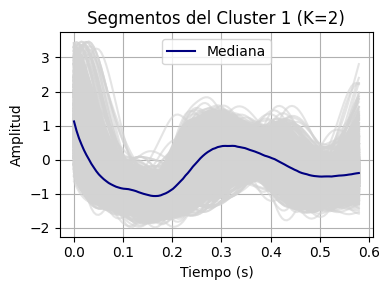

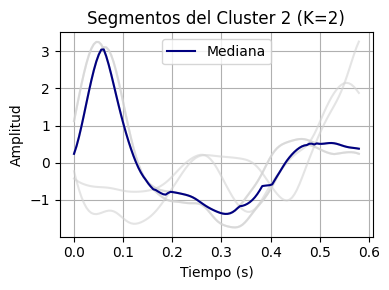

📏 Distancia promedio intracluster (K=2): 6.9211

🔹 K = 3


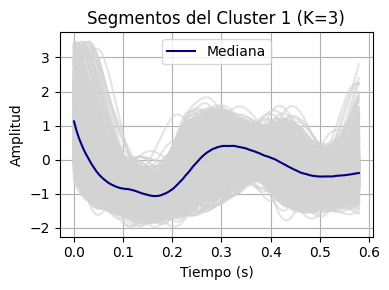

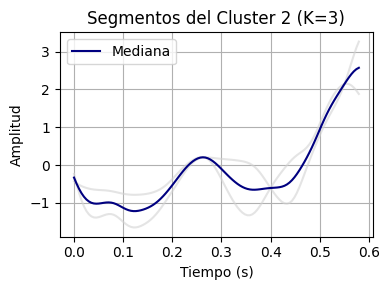

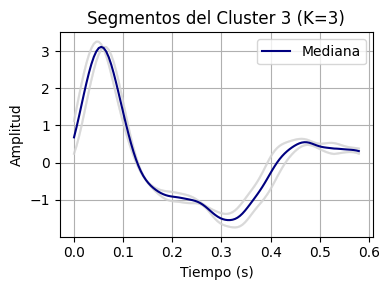

📏 Distancia promedio intracluster (K=3): 3.4283

🔹 K = 4


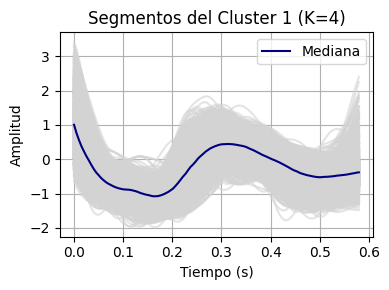

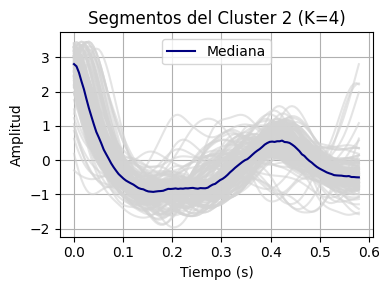

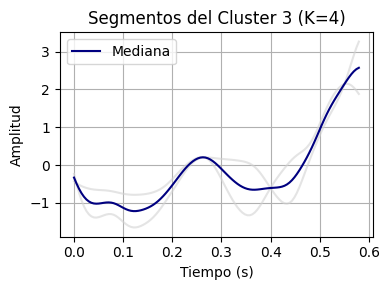

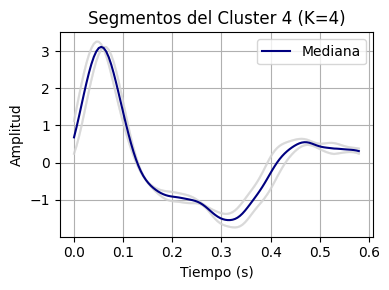

📏 Distancia promedio intracluster (K=4): 3.4136

🔹 K = 5


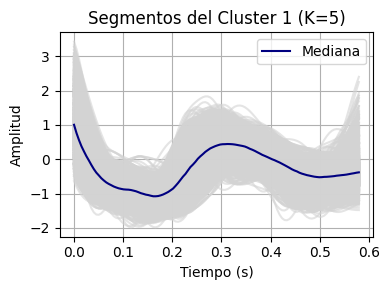

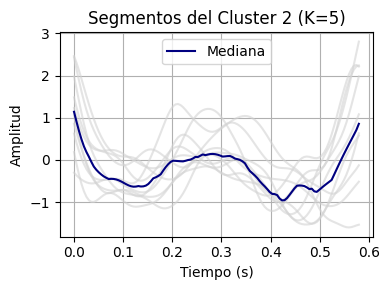

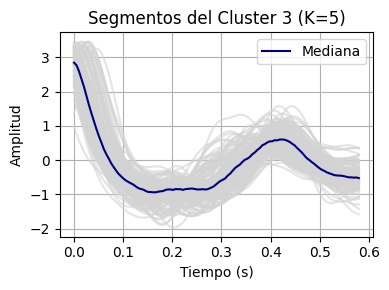

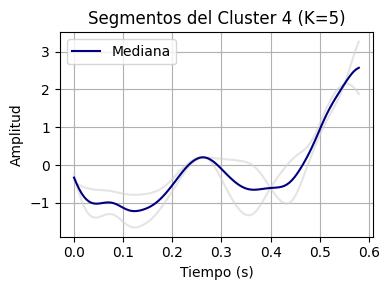

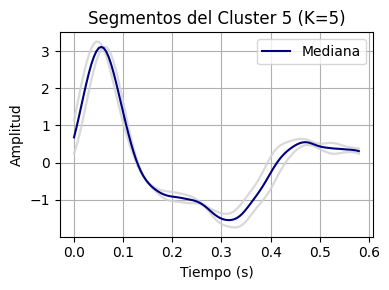

📏 Distancia promedio intracluster (K=5): 3.8714

🔹 K = 6


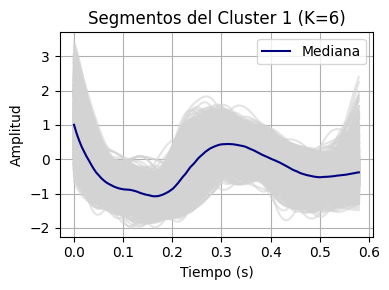

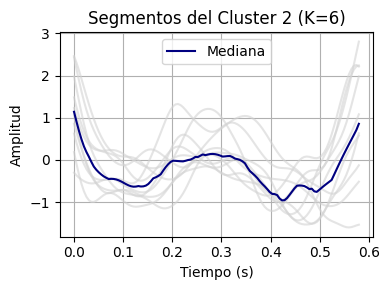

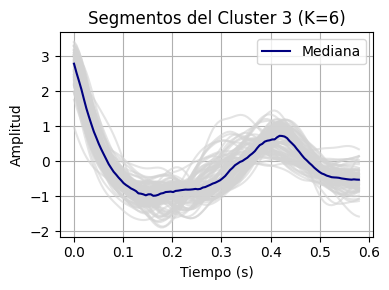

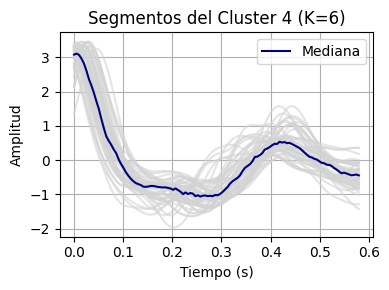

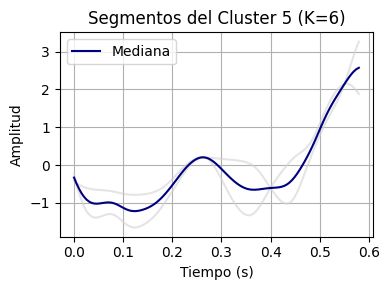

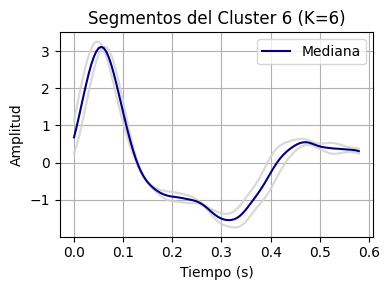

📏 Distancia promedio intracluster (K=6): 3.6603


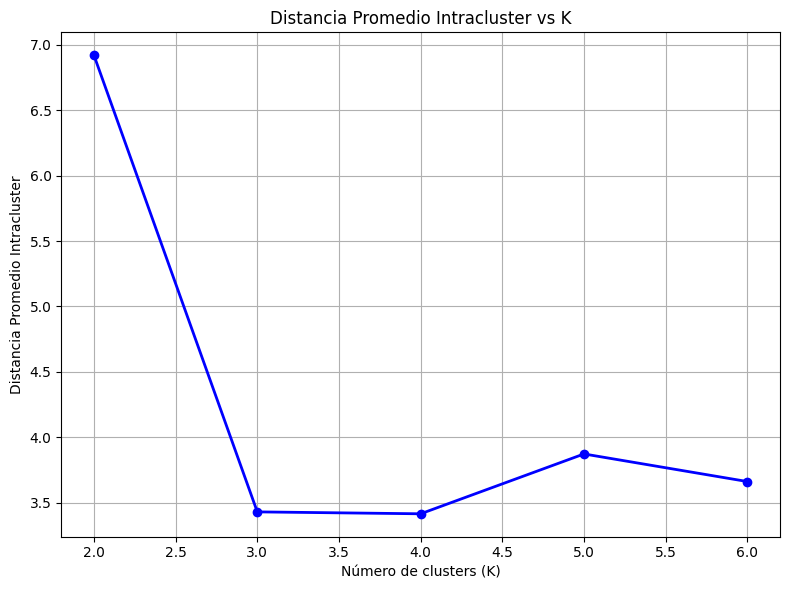

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from tslearn.metrics import cdist_dtw
from itertools import combinations

# Configuración
k_max = 6       # Número máximo de clusters a evaluar

# 1. Selección aleatoria de 1000 segmentos
v_segments_sample = v_segments['Segment_partial']
#.sample(n=1000, random_state=42).reset_index(drop=True)

# 2. Crear matriz de segmentos
segment_matrix = np.stack(v_segments_sample.values)

# 3. Vector de tiempo para graficar
time_vector = np.arange(segment_matrix.shape[1]) / FS

# 4. Calcular matriz de distancias DTW con restricción Sakoe-Chiba
print("Calculando matriz de distancias DTW...")
dtw_distances = cdist_dtw(
    segment_matrix,
    global_constraint="sakoe_chiba",
    sakoe_chiba_radius=int(0.1 * segment_matrix.shape[1])
)

# 5. Clustering jerárquico
print("Realizando clustering jerárquico...")
Z = linkage(dtw_distances, method='average')

# Para almacenar las distancias promedio por cada K
avg_intracluster_distances = []

# 6. Iterar sobre valores de k
for k in range(2, k_max + 1):
    print(f"\n🔹 K = {k}")

    # Obtener etiquetas
    labels = fcluster(Z, k, criterion='maxclust')

    intracluster_distances = []

    for cluster_id in range(1, k + 1):
        cluster_indices = np.where(labels == cluster_id)[0]
        cluster_segments = segment_matrix[cluster_indices]

        if len(cluster_segments) < 2:
            continue  # No se puede calcular distancia si hay 1 o 0 segmentos

        # Extraer submatriz de distancias intra-cluster
        pairwise_dists = [
            dtw_distances[i, j]
            for i, j in combinations(cluster_indices, 2)
        ]
        avg_dist = np.mean(pairwise_dists)
        intracluster_distances.append(avg_dist)

        # Gráfica del cluster
        representative = np.median(cluster_segments, axis=0)
        plt.figure(figsize=(4, 3))
        for segment in cluster_segments:
            plt.plot(time_vector, segment, color='lightgray', alpha=0.6)
        plt.plot(time_vector, representative, color='navy', linewidth=1.5, label='Mediana')
        plt.title(f'Segmentos del Cluster {cluster_id} (K={k})')
        plt.xlabel('Tiempo (s)')
        plt.ylabel('Amplitud')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Reporte de distancia promedio intracluster
    if intracluster_distances:
        avg_dist = np.mean(intracluster_distances)
        avg_intracluster_distances.append(avg_dist)
        print(f"📏 Distancia promedio intracluster (K={k}): {avg_dist:.4f}")
    else:
        print(f"⚠️ No se pudo calcular distancia intracluster (muy pocos segmentos por cluster).")

# 7. Graficar distancia promedio intracluster vs K
plt.figure(figsize=(8, 6))
plt.plot(range(2, k_max + 1), avg_intracluster_distances, marker='o', color='b', linestyle='-', linewidth=2)
plt.title('Distancia Promedio Intracluster vs K')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Distancia Promedio Intracluster')
plt.grid(True)
plt.tight_layout()
plt.show()


Con este método obtengo peores resultados que con el anterior porque cada cluster no tiene un número tan homogéneo de muestras sino que hay clusters formados por muchísimas muestras y otros formados por súper pocas muestras.